# 7. Differential Abundance Analysis

Microbiome differential abundance analysis is challenging due to sparsity, and strong sample-to-sample variability in the data. No single statistical method performs optimally across all community structures, effect sizes, or preprocessing choices. To obtain robust and biologically meaningful results, it is therefore common practice to apply multiple complementary methods and combine their outputs.
In this notebook, we perform differential abundance analysis using ANCOM, MaAsLin2, and DESeq2:

* ANCOM-BC accounts explicitly for the compositional constraints of microbiome data, controlling false discovery rates by comparing log-ratios between taxa. It is conservative but well-suited for detecting strong, consistent shifts.
* MaAsLin2 uses multivariable linear modeling with normalization and transformation steps tailored for microbial relative abundances. It is good in handling complex metadata (covariates, continuous variables, repeated measures).
* DESeq2 models count data using negative binomial distributions and robust size-factor normalization. It is sensitive to subtle changes and performs well on raw count matrices.

Because each method captures different aspects of the data and may produce partially overlapping sets of significant features, we generate a consensus set of taxa that are consistently detected across methods. This intersection provides a more stable and reproducible set of associations, minimizing method-specific artifacts and increasing confidence in the biological interpretations [[Nearing et al., 2022](https://doi.org/10.1038/s41467-022-28034-z)].

We will perform Differential analysis for Diet (breastfed dominant, formula fed dominant and mixed), Age (4, 7 and 10 months) and Ttreatment exposure (True or False). We will perform differential analysis for diet, age, and treatment exposure, while correcting for repeated measures using host_id as a random effect (ANCOM and MaAsLin2) or blocking factor (DESeq2).

### Notebook Structure

**0.** Setup    
**1.** Data Exploration  
**2.** ANCOM    
**3.** MaAsLin2  
**4.** DESeq2  
**5.** Consensus Set 

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
    
<b> Research questions this notebook answers:</b>
    
- How do the microbiome samples differ between different ages? What differences do you see in terms of geolocation? What could be covariates contributing to these changes?
    
- Some of your samples were exposed to some treatment (metadata column "treatment_exposure").  Did the treatment have an effect on the infant gut microbiome?  Does the effect of the treatment depend on other covariates?

</div>

## 0. Setup

In [1]:
# Import all necessary packages
import os
import matplotlib.pyplot as plt
import pandas as pd
import qiime2 as q2
from qiime2 import Visualization
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from math import sqrt
import numpy as np
%matplotlib inline

In [2]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/Project_final/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# Data directories
meta_data_dir = "../data/processed/metadata"
raw_data_dir = "../data/raw"
denoised_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
diversity_data_dir = "../data/processed/diversity"
phylogeny_data_dir = "../data/processed/phylogeny"
daa_data_dir = "../data/processed/differential_abundance"

In [4]:
%%bash -s "$daa_data_dir"
mkdir -p "$1"

# 1. Data Exploration: look at feature table and data distribution

We want to have a look at the feature table to check if it is sparse (a lot of zero-values) and to have a look at the data distribution. We can see in the table that there are quite a lot of zero-values and from the violin-plot we can see that the data is not normally distributed. We additionally did the Shapiro-Wilk test to check if the data is normally distributed, since we only plotted 15 samples. Further down in the results we can see that the data indeed is not normally distributed.

In [7]:
#import and plot feature table to check for zero-values
data = q2.Artifact.load(f'{taxonomy_data_dir}/dada2_table_filtered.qza').view(pd.DataFrame)

In [8]:
data.head()

,fc3da5e771a4cdfa712edbbee476b8a7,c00fffeaa7a0dea8667abe01b29d43f1,c82b5f586720941cad67e47c54bf52b0,424e0b100046c6569ece966c20d7a62b,426f0d4e0a618b66f88da128c8f402bb,961065d7bd74b5d555507e9990906fcf,54d47aa0ead9c6c9495f9c5ea99b5766,04cba8d7b04f07af7f526eb2cd865894,6d972bf46f316822e6cd6589284c85cf,92b1614e9ed25cc5401e947641d437b6,...,490f800441303542c501eca4c0de9405,b0a59f757e14045609c382751c5fbd60,f3623f4f4eddb6b0c0011373a2f6258d,e203565a652acf24c8ac539360ff9e02,4ead1d286790ba06bdc1f2eef43c1932,fde3ed10047c36478bcf6f7bd2c402ef,7104a1668767eccfc706812138f7619f,e266c7a4a98b9bba0f8441c8c0e94660,6ac9f3653529148a314296fe14c6d601,9b3d38779468620f7fdfae13dab0b5b8
SRR8115637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115646,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115666,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115682,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SRR8115685,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
#violin plot to check if data is normally distributed
n = 15

# draw n ASVs out of the original DataFrame
data_samp = data.sample(n=n, axis=1, random_state=234)

# create a new DataFrame with three columns (sample, ASV, abundance)
col_names = {'level_0': 'sample', 'level_1': 'asv', 0: 'count'}
data_plot = data_samp.stack().reset_index().rename(columns=col_names)

# make sure the shape is correct (no. of rows should be equal to the size of our random 
# sample multiplied by number of samples)
assert data_plot.shape[0] == n * data_samp.shape[0], 'The new DataFrame has an incorrect no. of rows.'

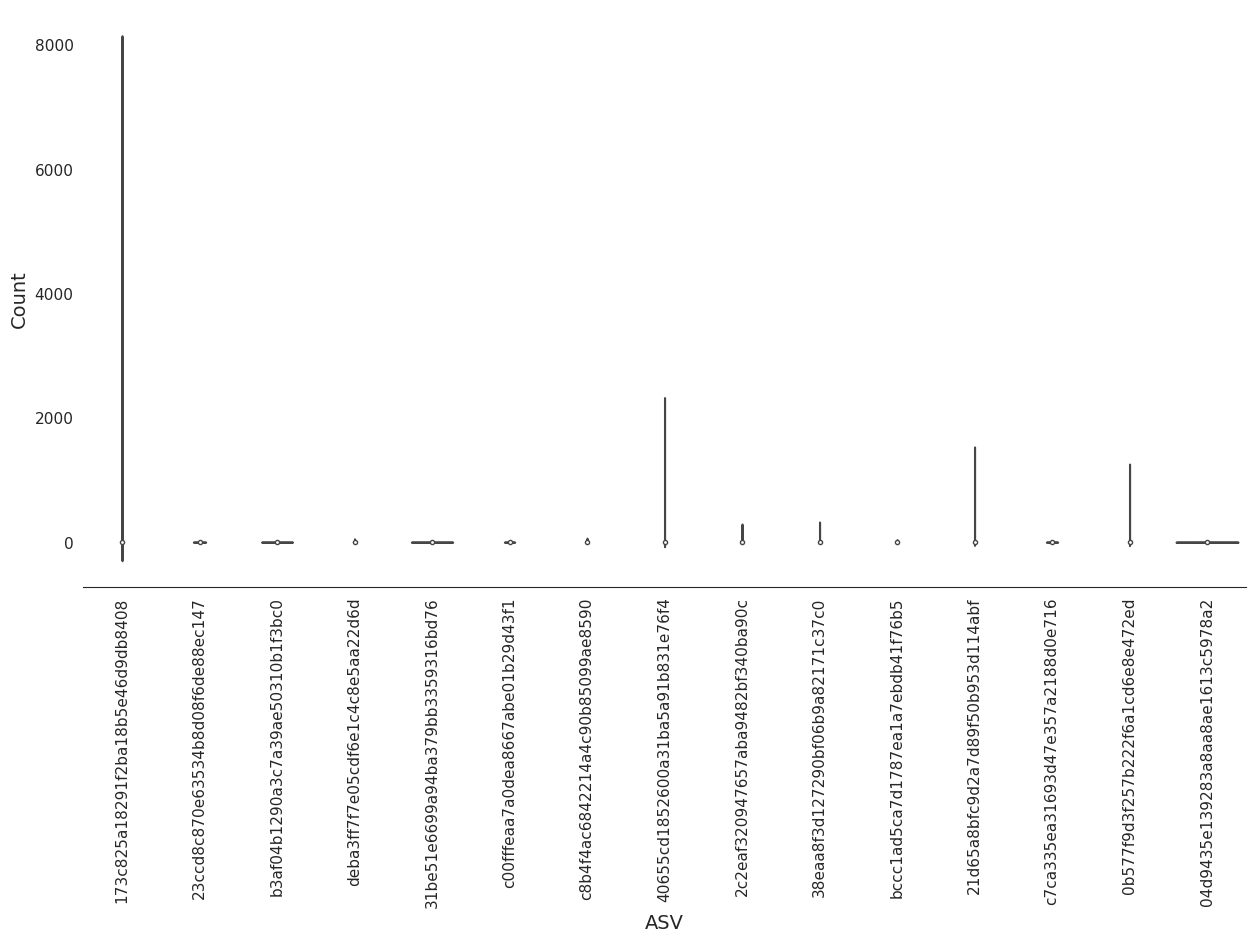

In [10]:
with sns.axes_style('white'), sns.color_palette('Set1'):
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 7.5)
    
    sns.violinplot(data=data_plot, x='asv', y='count', ax=ax)
    sns.despine(left=True)
    
    # adjust tick labels and axes titles
    ax.tick_params(axis='x', rotation=90, labelsize=11)
    ax.tick_params(axis='y', labelsize=11)
    ax.set_xlabel('ASV', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

In [11]:
#statistically testing for normality 
alpha = 0.05
results = {}

# iterate through rows (samples) and test each of them for normality
for asv_name, asv_values in data.items():
    stat, p = shapiro(asv_values)
    results[asv_name] = p

# convert test results into a DataFrame
results_df = pd.DataFrame(data=results.values(), index=results.keys(), columns=['p'])

# add a new column with a descriptive test result
results_df['is_normal'] = results_df['p'] > alpha

In [12]:
results_df

,p,is_normal
fc3da5e771a4cdfa712edbbee476b8a7,1.802703e-38,False
c00fffeaa7a0dea8667abe01b29d43f1,0.000000e+00,False
c82b5f586720941cad67e47c54bf52b0,0.000000e+00,False
424e0b100046c6569ece966c20d7a62b,5.453102e-38,False
426f0d4e0a618b66f88da128c8f402bb,0.000000e+00,False
...,...,...
fde3ed10047c36478bcf6f7bd2c402ef,0.000000e+00,False
7104a1668767eccfc706812138f7619f,0.000000e+00,False
e266c7a4a98b9bba0f8441c8c0e94660,0.000000e+00,False
6ac9f3653529148a314296fe14c6d601,0.000000e+00,False


In [13]:
print('Number of ASVs with normal distribution:', results_df['is_normal'].sum())

Number of ASVs with normal distribution: 0


# 2. ANCOM-BC
The first method that we use is ANCOM-BC, Analysis of Compositions of Microbiomes with Bias Correction, which is a rather conservative method when compared to other methods for differential abundance analysis. So it will set a good base for our consenus set [[Nearing et al., 2022].(https://doi.org/10.1038/s41467-022-28034-z)] ANCOM-BC estimates the unknown sampling fractions and corrects the bias induced by their differences among samples. ANCOM uses relative abundances to infer about absolute abundances. One of the deficiencies of ANCOM is that it does not provide p value for individual taxon, nor can it provide standard errors or confidence intervals of DA for each taxon, and it can be computationally intensive [[Lin et al., 2020](https://doi.org/10.1038/s41467-020-17041-7)].

We will use BH as a p-value adjustment method since it is less conservative than holm (default), but still controls FDR.

### Diet Milk (ANCOM-BC)

In [14]:
# create folder for diet
!mkdir -p "$daa_data_dir/ANCOM/diet"

We need to add the taxonomy to our feature table once and can reuse it for all other ancom runs.

In [16]:
! qiime feature-table filter-features \
    --i-table $taxonomy_data_dir/dada2_table_filtered.qza \
    --p-min-frequency 25 \
    --p-min-samples 4 \
    --o-filtered-table $daa_data_dir/table_abund.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund.qza


In [18]:
! qiime taxa collapse \
    --i-table $daa_data_dir/table_abund.qza \
    --i-taxonomy $taxonomy_data_dir/taxonomy.qza \
    --p-level 6 \
    --o-collapsed-table $daa_data_dir/table_abund_l6.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/table_abund_l6.qza


We now filter the abundance table by breast dominant and formula dominant diet to compare these two groups in the ancom test.

In [19]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[diet_milk]='bd' or [diet_milk]='fd'" \
    --o-filtered-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/diet/table_abund_diet.qza


In [20]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/diet/table_abund_diet.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula diet_milk \
    --p-p-adj-method BH \
    --o-differentials $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/diet/ancombc_diet_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an AP

In [248]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_da_barplot.qzv")

<visualization: Visualization uuid: a0601361-1ac2-427f-8a7a-d86d7dac6b43>

In this plot we can see the enriched and depleted features between the two diet groups. This gives us a first idea of what features could be significantly differnetially expressed but we have no info on significance yet.

In [249]:
Visualization.load(f"{daa_data_dir}/ANCOM/diet/ancombc_diet_results.qzv")

<visualization: Visualization uuid: 4878b499-7ecb-4eeb-bc31-15c9fad76356>

This table now contains the values for Log-Fold Change, p-values and q-values which we will use further down in the notebook to build the consensus set.

The steps for all the other ancom runs are the same as for diet, so there is no extra explanations for the individual steps and plots.

### Age in months (ANCOM-BC)

In [250]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/age"

In [251]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Add a prefix so values cannot be parsed as numbers
meta["age_group"] = meta["age_months"].astype(str).str.replace('.0', '', regex=False)
meta["age_group"] = "m" + meta["age_group"]   # m4, m7, m10

meta.to_csv(f"{daa_data_dir}/metadata_age_str.tsv", sep="\t", index=False)


In [25]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-where "[age_group]='m4' OR [age_group]='m10'" \
    --o-filtered-table $daa_data_dir/ANCOM/age/table_abund_age.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/age/table_abund_age.qza


In [26]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/age/table_abund_age.qza \
    --m-metadata-file $daa_data_dir/metadata_age_str.tsv \
    --p-formula age_group \
    --p-p-adj-method BH \
    --p-reference-levels age_group::m4 \
    --o-differentials $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_differentials.qza


In [27]:
# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/age/ancombc_age_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/age/ancombc_age_results.qzv


In [28]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_da_barplot.qzv")

<visualization: Visualization uuid: f1ca2ac6-5a78-4d6b-be77-b2e6d3564be9>

In [29]:
Visualization.load(f"{daa_data_dir}/ANCOM/age/ancombc_age_results.qzv")

<visualization: Visualization uuid: 603216c6-c85a-4013-a992-d29078552c56>

### Treatment exposure (ANCOM-BC)

In [30]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/treatment"

In [31]:
# treatment exposure has boolean values in meta data, so it needs to be changed to a string for this analysis
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")

# Convert booleans to strings
meta["treatment_exposure_str"] = meta["treatment_exposure"].astype(str)

# Add a prefix 
meta["treatment_exposure_str"] = "t_" + meta["treatment_exposure_str"]   # t_True, t_False

# Save back
meta.to_csv(f"{daa_data_dir}/metadata_treatment_str.tsv", sep="\t", index=False)

In [32]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $daa_data_dir/metadata_treatment_str.tsv \
    --p-where "[treatment_exposure_str]='t_True' or [treatment_exposure_str]='t_False'" \
    --o-filtered-table $daa_data_dir/ANCOM/treatment/table_abund_treatment.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/treatment/table_abund_treatment.qza


In [33]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/treatment/table_abund_treatment.qza \
    --m-metadata-file $daa_data_dir/metadata_treatment_str.tsv \
    --p-formula treatment_exposure_str \
    --p-p-adj-method BH \
    --o-differentials $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/treatment/ancombc_treatment_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/treatment/ancombc_treatment_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/treatment/ancombc_treatment_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/treatment/ancombc_treatment_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is

In [34]:
Visualization.load(f"{daa_data_dir}/ANCOM/treatment/ancombc_treatment_da_barplot.qzv")

<visualization: Visualization uuid: 124f9bee-50c5-4c71-b392-69228fe07841>

In [35]:
Visualization.load(f"{daa_data_dir}/ANCOM/treatment/ancombc_treatment_results.qzv")

<visualization: Visualization uuid: 96bf548d-7f03-495b-9485-31522669bf8d>

### Delivery Mode (ANCOM-BC)

In [40]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/deliverymode"

In [41]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[delivery_mode]='vaginal' or [delivery_mode]='cesarean'" \
    --o-filtered-table $daa_data_dir/ANCOM/deliverymode/table_abund_deliverymode.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/deliverymode/table_abund_deliverymode.qza


In [42]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/deliverymode/table_abund_deliverymode.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-formula delivery_mode \
    --p-p-adj-method BH \
    --o-differentials $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/differential_abundance/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_

In [44]:
Visualization.load(f"{daa_data_dir}/ANCOM/deliverymode/ancombc_deliverymode_da_barplot.qzv")

<visualization: Visualization uuid: 0841d8c8-7903-4fd2-9534-b7f3857fc357>

In [45]:
Visualization.load(f"{daa_data_dir}/ANCOM/deliverymode/ancombc_deliverymode_results.qzv")

<visualization: Visualization uuid: 54b53307-c92b-4483-aa4e-6e9d113c34a1>

### Geolocation (ANCOM-BC)

In [50]:
# create folder for age
!mkdir -p "$daa_data_dir/ANCOM/geolocation"

We will look at the difference between Russia and Finland since these are developmentally furthest apart and therefore we expect the largest difference between these countries.

In [55]:
! qiime feature-table filter-samples \
    --i-table $daa_data_dir/table_abund_l6.qza \
    --m-metadata-file $meta_data_dir/metadata_merged.tsv \
    --p-where "[geo_location_name]='Russia' or [geo_location_name]='Finland'" \
    --o-filtered-table $daa_data_dir/ANCOM/geolocation/table_abund_geolocation.qza

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/differential_abundance/ANCOM/geolocation/table_abund_geolocation.qza


In [64]:
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t")
meta_no_est = meta[meta["geo_location_name"] != "Estonia"]

meta_no_est.to_csv(f"{daa_data_dir}/metadata_no_estonia.tsv", sep="\t", index=False)

In [65]:
# Run ANCOM-BC
! qiime composition ancombc \
    --i-table $daa_data_dir/ANCOM/geolocation/table_abund_geolocation.qza \
    --m-metadata-file $daa_data_dir/metadata_no_estonia.tsv \
    --p-formula geo_location_name \
    --p-p-adj-method BH \
    --o-differentials $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza

# Generate a barplot of differentially abundant taxa between environments
! qiime composition da-barplot \
    --i-data $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_da_barplot.qzv

# Generate a table of these same values for all taxa
! qiime composition tabulate \
    --i-data $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
    --o-visualization $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_results.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureData[DifferentialAbundance] to: ../data/processed/differential_abundance/ANCOM/geolocation/ancombc_geolocation_differentials.qza


In [67]:
Visualization.load(f"{daa_data_dir}/ANCOM/geolocation/ancombc_geolocation_da_barplot.qzv")

<visualization: Visualization uuid: c8b74d77-6ec9-4b63-a13b-b8ae2b92cf6f>

In [ ]:
Visualization.load(f"{daa_data_dir}/ANCOM/geolocation/ancombc_geolocation_results.qzv")

## Volcano Plots
We will now create Volcano Plots for all ANCOM results. For this we will first export the qiime results and create a single dataframe for each of the metadata groups.

In [68]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/age/ancombc_age_differentials.qza \
      --output-path $daa_data_dir/ANCOM/age/ancombc_export_age

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/age/ancombc_age_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/age/ancombc_export_age


In [69]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/diet/ancombc_diet_differentials.qza \
      --output-path $daa_data_dir/ANCOM/diet/ancombc_export_diet

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/diet/ancombc_diet_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/diet/ancombc_export_diet


In [70]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/treatment/ancombc_treatment_differentials.qza \
      --output-path $daa_data_dir/ANCOM/treatment/ancombc_export_treatment

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/treatment/ancombc_treatment_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/treatment/ancombc_export_treatment


In [71]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza \
      --output-path $daa_data_dir/ANCOM/deliverymode/ancombc_export_deliverymode

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/deliverymode/ancombc_deliverymode_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/deliverymode/ancombc_export_deliverymode


In [72]:
! qiime tools export \
      --input-path $daa_data_dir/ANCOM/geolocation/ancombc_geolocation_differentials.qza \
      --output-path $daa_data_dir/ANCOM/geolocation/ancombc_export_geolocation

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/ANCOM/geolocation/ancombc_geolocation_differentials.qza as DataLoafPackageDirFmt to directory ../data/processed/differential_abundance/ANCOM/geolocation/ancombc_export_geolocation


In [6]:
#This function is used to create one results table for each metadata category.
def load_ancombc_results(daa_data_dir, variable, effect):
    """
    Loads ANCOM-BC exported differential abundance for a given variable 
    (age, diet, treatment) and merges all slices into a single DataFrame.
    
    Parameters
    ----------
    daa_data_dir: str
    variable : str
        Name of the variable folder, e.g. "age", "diet", "treatment".
    effect : str
        Column name representing the effect term in the ANCOM tables.

    Returns
    -------
    pandas.DataFrame
        Clean merged dataframe 
    """

    path = f"{daa_data_dir}/ANCOM/{variable}/ancombc_export_{variable}/"

    # Load slices
    lfc  = pd.read_csv(path + "lfc_slice.csv")
    pval = pd.read_csv(path + "p_val_slice.csv")
    qval = pd.read_csv(path + "q_val_slice.csv")
    se   = pd.read_csv(path + "se_slice.csv")
    w    = pd.read_csv(path + "w_slice.csv")

    # Merge into one table
    df = (
        lfc[["id", effect]].rename(columns={effect: "lfc"})
        .merge(pval[["id", effect]].rename(columns={effect: "p_val"}), on="id")
        .merge(qval[["id", effect]].rename(columns={effect: "q_val"}), on="id")
        .merge(se[["id", effect]].rename(columns={effect: "se"}), on="id")
        .merge(w[["id", effect]].rename(columns={effect: "w"}), on="id")
    )

    # Remove missing q-values
    df = df.dropna(subset=["q_val", "lfc"])

    # Add -log10(q)
    df["minus_log10_q"] = -np.log10(df["q_val"] + 1e-300)

    return df


This function creates volcano plots for each group containing labels for the top five differentially abundant features. Some features were not classified up to genus, which is why they are labeled with a hyphen. For further analysis we will focus on the ones that were classified to the genus level.

In [7]:
#This function is used to create and display the volcano plots

#Helper function for labeling
def shorten_taxon(taxon):
    """Return only the last non-empty level"""
    parts = [p for p in taxon.split(";") if p]
    return parts[-1] if parts else taxon

def volcano_plot_ancombc(df, effect_label, alpha=0.05, lfc_thresh=1):
    """
    Creates a volcano plot for ANCOM-BC results.

    Parameters
    ----------
    df : pandas.DataFrame
        Table from load_ancombc_results()
    effect_label : str
        Title label to display
    alpha : float
        Significance cutoff for q-values.
    lfc_thresh : float
        Threshold for |log fold change|
    """

    df = df.copy()
    df["-log10_q"] = -np.log10(df["q_val"] + 1e-300)

    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["q_val"] < alpha) & (df["lfc"] <= -lfc_thresh), "sig"] = "Down"

    colors = {
        "Up": "red",
        "Down": "blue",
        "Not significant": "grey"
    }

    plt.figure(figsize=(8,6), dpi=120)

    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["lfc"],
            subset["-log10_q"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )
    
    
    # Label most significant features (lowest q-values)
    top3 = df.sort_values("q_val").head(5)

    for _, row in top3.iterrows():
        label = shorten_taxon(row["id"])
        plt.annotate(
            label,
            (row["lfc"], row["-log10_q"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
        )

    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)

    plt.xlabel("lfc")
    plt.ylabel("-log_10(q-value)")
    plt.title(f"Volcano Plot (ANCOM-BC) – {effect_label}")
    plt.legend()
    plt.tight_layout()
    plt.show()

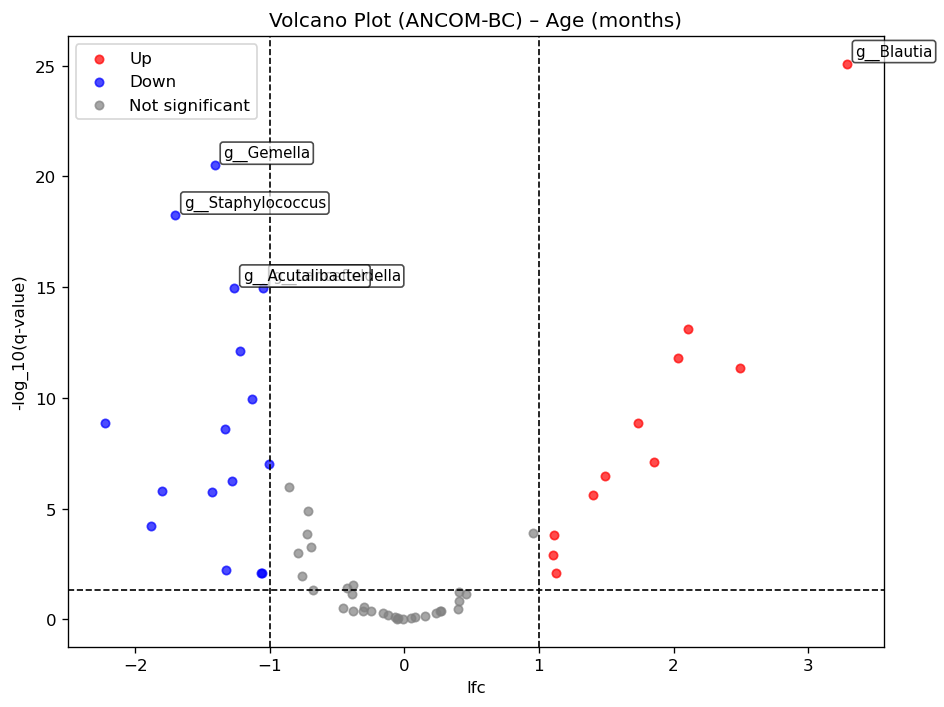

In [8]:
#age
variable = "age"               
effect = "age_groupm10"        
label = "Age (months)"         

df_ancom_age = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_age, label)

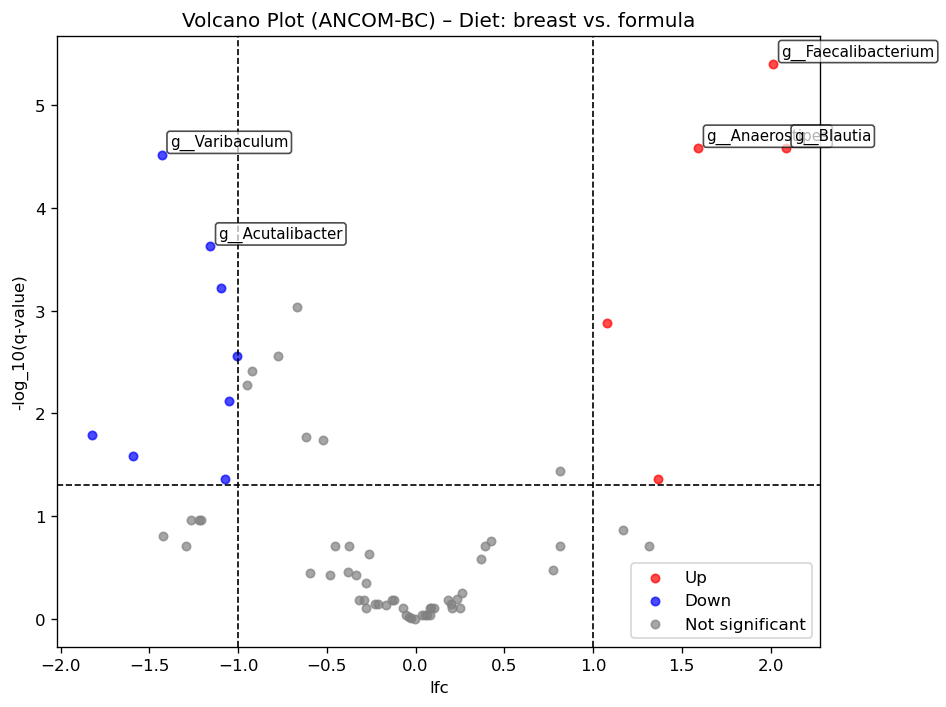

In [9]:
#diet
variable = "diet"
effect = "diet_milkfd"
label = "Diet: breast vs. formula"

df_ancom_diet = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_diet, label)

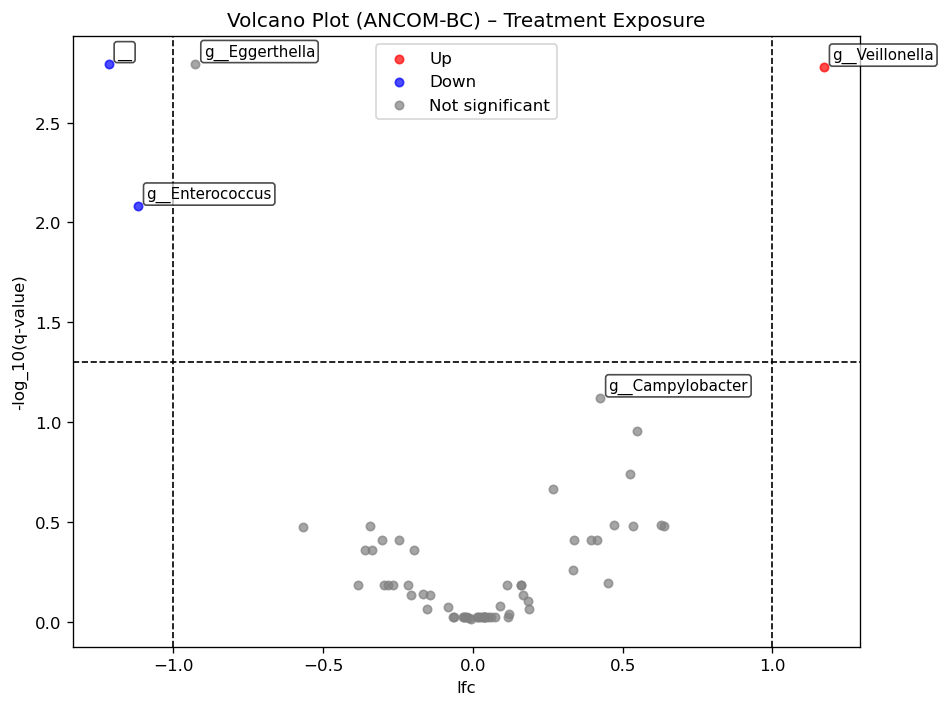

In [10]:
#treatment exposure
variable = "treatment"
effect = "treatment_exposure_strt_True" 
label = "Treatment Exposure"

df_ancom_treatment = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_treatment, label)

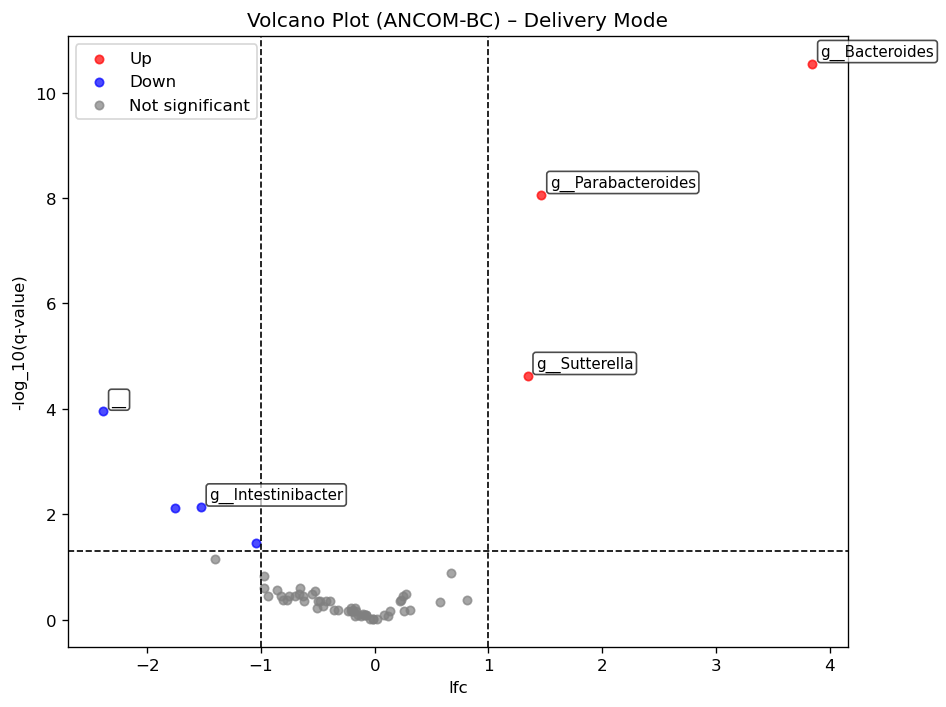

In [11]:
#delivery mode
variable = "deliverymode"               
effect = "delivery_modevaginal"        
label = "Delivery Mode"         

df_ancom_deliverymode = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_deliverymode, label)

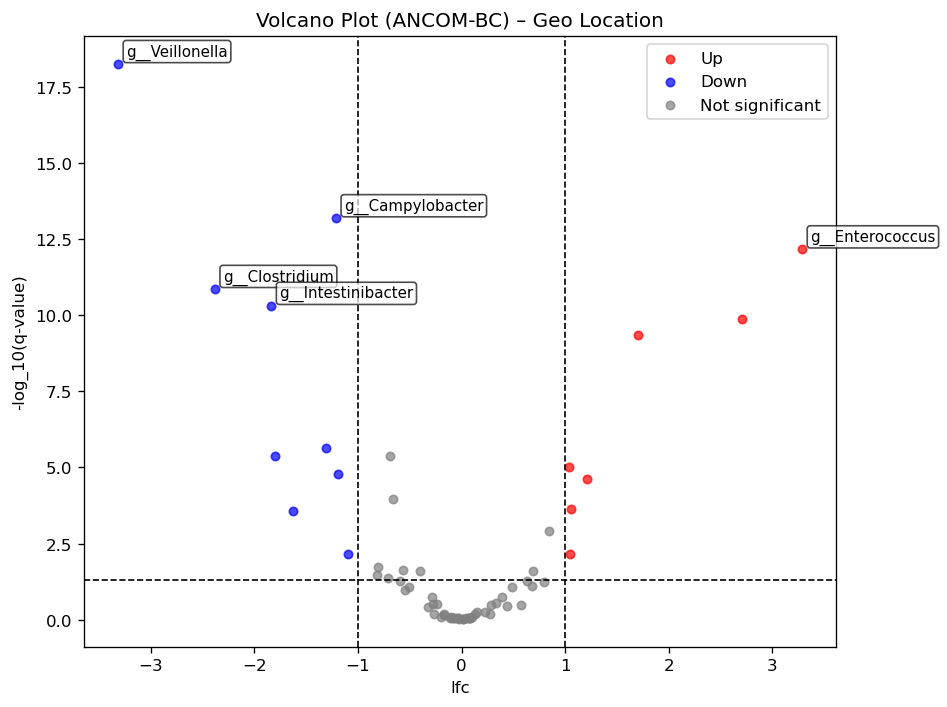

In [12]:
#geo location
variable = "geolocation"               
effect = "geo_location_nameRussia"        
label = "Geo Location"         

df_ancom_geolocation = load_ancombc_results(daa_data_dir, variable, effect)
volcano_plot_ancombc(df_ancom_geolocation, label)

# 3. MaAsLin2

The second method we use is MaAsLin2. It has shown to be identify more differentially abundant taxa than ANCOM, but also to be consistent across different datasets. MaAsLin2 finds associations between microbiome multi-omics features and complex metadata in population-scale epidemiological studies. The software includes multiple analysis methods (including support for multiple covariates and repeated measures), filtering, normalization, and transform options [[MaAsLin2 Tutorial](https://github.com/biobakery/Maaslin2)].

To make the results most comparable to the ANCOM-BC reuslts we we use a linear model (LM) since it is the most robust. For the transformation we use 'TSS' (Total Sum Scaling) since ANCOM works on compositional data and using 'TSS' we get compositional data. We log-normalize our data since ANCOM-BC does this internally. The p-adjustment method used for both methods is 'BH' (default for MaAsLin2 is 'fdr' which is equivalent to 'BH').

In [12]:
# create folder for MaAsLin
!mkdir -p "$daa_data_dir/maaslin"

Since MaAsLin2 is not a qiime package, but runs in R, we need to export our abundance table as well as our feature table. 

In [13]:
! qiime tools export \
    --input-path $daa_data_dir/table_abund_l6.qza \
    --output-path $daa_data_dir/table_abund_l6_export

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/differential_abundance/table_abund_l6.qza as BIOMV210DirFmt to directory ../data/processed/differential_abundance/table_abund_l6_export


In [14]:
! biom convert \
    -i $daa_data_dir/table_abund_l6_export/feature-table.biom \
    -o $daa_data_dir/table_abund_l6_export/feature-table.tsv \
    --to-tsv

This cell is needed so we can have R cells in our notebook.

In [15]:
# enable R in Jupyter Notebook
%load_ext rpy2.ipython

The following cell needs to be run every time the serves has disconnected and takes about 20 minutes. 

In [ ]:
%%R
install.packages("remotes", quit=True)
remotes::install_github("biobakery/Maaslin2")

### Age in months (MaAsLin2)

In [ ]:
%%R --i daa_data_dir
library(Maaslin2)

#age
tmp <- capture.output({
    fit <- Maaslin2(
        input_data = file.path(daa_data_dir,"table_abund_l6_export", "feature-table.tsv"),
        input_metadata = file.path(daa_data_dir, "metadata_age_str.tsv"),
        output = file.path(daa_data_dir, "maaslin", "maaslin2_age"),
        normalization = "TSS",
        transform = "LOG",
        analysis_method = "LM",
        fixed_effects = c("age_group"),
        reference = c("age_group,m4"),
        random_effects = c("host_id"),
    )
})

### Diet (MaAsLin2)

In [ ]:
%%R --i daa_data_dir --i meta_data_dir
library(Maaslin2)

#diet
tmp <- capture.output({
    fit <- Maaslin2(
        input_data = file.path(daa_data_dir,"table_abund_l6_export", "feature-table.tsv"),
        input_metadata = file.path(meta_data_dir, "metadata_merged.tsv"),
        output = file.path(daa_data_dir, "maaslin", "maaslin2_diet"),
        normalization = "TSS",
        transform = "LOG",
        analysis_method = "LM",
        fixed_effects = c("diet_milk"),
        reference = c("diet_milk,bd"),
        random_effects = c("host_id"),
    )
})

### Treatment Exposure (MaAsLin2)

In [ ]:
%%R --i daa_data_dir --i meta_data_dir
library(Maaslin2)

#treatment exposure
tmp <- capture.output({
    fit <- Maaslin2(
        input_data = file.path(daa_data_dir,"table_abund_l6_export", "feature-table.tsv"),
        input_metadata = file.path(meta_data_dir, "metadata_merged.tsv"),
        output = file.path(daa_data_dir, "maaslin", "maaslin2_treatment"),
        normalization = "TSS",
        transform = "LOG",
        analysis_method = "LM",
        fixed_effects = c("treatment_exposure"),
        random_effects = c("host_id"),
    )
})

### Delivery Mode (MaAsLin2)

In [ ]:
%%R --i daa_data_dir --i meta_data_dir
library(Maaslin2)

#delivery mode
tmp <- capture.output({
    fit <- Maaslin2(
        input_data = file.path(daa_data_dir,"table_abund_l6_export", "feature-table.tsv"),
        input_metadata = file.path(meta_data_dir, "metadata_merged.tsv"),
        output = file.path(daa_data_dir, "maaslin", "maaslin2_deliverymode"),
        normalization = "TSS",
        transform = "LOG",
        analysis_method = "LM",
        fixed_effects = c("delivery_mode"),
        random_effects = c("host_id"),
    )
})

### Geo Location (MaAsLin2)

In [ ]:
%%R --i daa_data_dir --i meta_data_dir
library(Maaslin2)

#geo location
tmp <- capture.output({
    fit <- Maaslin2(
        input_data = file.path(daa_data_dir,"table_abund_l6_export", "feature-table.tsv"),
        input_metadata = file.path(meta_data_dir, "metadata_merged.tsv"),
        output = file.path(daa_data_dir, "maaslin", "maaslin2_geolocation"),
        normalization = "TSS",
        transform = "LOG",
        analysis_method = "LM",
        fixed_effects = c("geo_location_name"),
        reference = c("geo_location_name,Russia"),
        random_effects = c("host_id"),
    )
})

## Volcano Plots (MaAsLin2)
The following cell is used to create and display the volcano plots from the MaAsLin2 results with labels for the 5 most significantly differnentially abundant features. Again the labels show the genus, so the features not classified up to genus are labeled with a hyphen.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Map metadata variables to their output folder names
maaslin_paths = {
    "age_months": f"{daa_data_dir}/maaslin/maaslin2_age/all_results.tsv",
    "diet_milk": f"{daa_data_dir}/maaslin/maaslin2_diet/all_results.tsv",
    "treatment_exposure": f"{daa_data_dir}/maaslin/maaslin2_treatment/all_results.tsv",
    "delivery_mode": f"{daa_data_dir}/maaslin/maaslin2_deliverymode/all_results.tsv",
    "geo_location_name": f"{daa_data_dir}/maaslin/maaslin2_geolocation/all_results.tsv",
}

def shorten_taxon(taxon):
    """Return only the last non-empty level"""
    parts = [p for p in taxon.split(".") if p]
    return parts[-1] if parts else taxon

# Volcano plot function
def volcano_plot(result_path, metadata_var, qval_threshold=0.05, top_n=10):

    # Load the correct results file
    df = pd.read_csv(result_path, sep="\t")
    
    # Filter for the metadata variable
    df_meta = df[df['metadata'] == metadata_var].copy()
    if df_meta.empty:
        print(f"No results found for {metadata_var} in {result_path}")
        return
    
    # Calculate -log10 p-value
    df_meta['neg_log10_pval'] = -np.log10(df_meta['pval'])
    
    # Define significance
    df_meta['significant'] = df_meta['qval'] < qval_threshold
    
    # Plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        data=df_meta,
        x='coef',
        y='neg_log10_pval',
        hue='significant',
        palette={True: 'red', False: 'grey'},
        edgecolor=None
    )
    
    # Horizontal line for q-value threshold
    plt.axhline(-np.log10(qval_threshold), linestyle='--', color='black', alpha=0.7)
    
    # label most significant features
    top_df = df_meta.sort_values("qval").head(5)

    for _, row in top_df.iterrows():
        label = shorten_taxon(row["feature"])
        plt.annotate(
            label,
            (row["coef"], row["neg_log10_pval"]),
            textcoords="offset points",
            xytext=(5, 5),
            ha='left',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
        )

    
    plt.xlabel('Effect Size (Coefficient)')
    plt.ylabel('-log10(p-value)')
    plt.title(f'Volcano Plot (MaAsLin2): {metadata_var}')
    plt.legend(title='Significant')
    plt.tight_layout()
    plt.show()


# === Run volcano plots for each variable ===

volcano_plot(maaslin_paths["treatment_exposure"], metadata_var="treatment_exposure")
volcano_plot(maaslin_paths["age_months"], metadata_var="age_group")
volcano_plot(maaslin_paths["diet_milk"], metadata_var="diet_milk")
volcano_plot(maaslin_paths["delivery_mode"], metadata_var="delivery_mode")
volcano_plot(maaslin_paths["geo_location_name"], metadata_var="geo_location_name")

# 4. DESeq2

The third method we will use is DESeq2. It provides methods to test for differential expression by use of negative binomial generalized linear models; the estimates of dispersion and logarithmic fold changes incorporate data-driven prior distributions [[DESeq2 Tutorial](https://bioconductor.org/packages//release/bioc/vignettes/DESeq2/inst/doc/DESeq2.html)].

To make DESeq2 comparable with ANCOM-BC and MaAsLin2 we use DESeq's built-in normalization (type="poscounts" for sparse microbiome data) and a negative binomial GLM with Wald test. The p-value adjustment is again 'BH'.

In [5]:
# create folder for delivery mode
!mkdir -p "$daa_data_dir/DESeq2"

DESeq2, like MaAsLin2, isn't a qiime package so we again need to run it in R cells in our notebook. To do so we load the previously exported featurw table and create a counts and a meta dataframe containing our taxonomy and metadata.

In [6]:
# Load the feature table (TSV)
feature_table = pd.read_csv(f"{daa_data_dir}/table_abund_l6_export/feature-table.tsv", sep="\t", skiprows=1)
feature_table = feature_table.rename(columns={"#OTU ID": "Taxon"})

# Set taxonomy as the index
feature_table = feature_table.set_index("Taxon")

# Load metadata
meta = pd.read_csv(f"{meta_data_dir}/metadata_merged.tsv", sep="\t", index_col=0)

In [7]:
counts = feature_table  # taxonomy as rows, samples as columns

# Match metadata samples
shared = meta.index.intersection(counts.columns)

counts = counts[shared]
meta = meta.loc[shared]

print(counts.shape, meta.shape)

(176, 357) (357, 9)


In [14]:
# run R in Jupyter notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


The following cell needs to be run every time and takes about 1 hour. Please select CRAN mirror 60 and choose to update all the packages. We used the Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29).  

In [16]:
%%R
invisible(capture.output({
    install.packages("BiocManager", quiet = TRUE)
    BiocManager::install("DESeq2", ask = FALSE, quiet = TRUE)
}))

R[write to console]: Updating HTML index of packages in '.Library'

R[write to console]: Making 'packages.html' ...
R[write to console]:  done

R[write to console]: 'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://stat.ethz.ch/CRAN

R[write to console]: Bioconductor version 3.18 (BiocManager 1.30.27), R 4.3.3 (2024-02-29)

R[write to console]: Old packages: 'Cairo', 'ragg', 'systemfonts', 'textshaping'

R[write to console]: Updating HTML index of packages in '.Library'

R[write to console]: Making 'packages.html' ...
R[write to console]:  done



In [17]:
%%R -i counts -i meta -i daa_data_dir

library(DESeq2)

run_deseq2 <- function(counts,
                       meta,
                       daa_data_dir,
                       design_vars,
                       block = NULL) {

  # check that variables exist
  all_vars <- design_vars
  if (!is.null(block)) {
    if (!(block %in% colnames(meta))) 
      stop("Block variable not found in metadata: ", block)
    all_vars <- c(block, design_vars)   # block first
  }

  missing_vars <- setdiff(all_vars, colnames(meta))
  if (length(missing_vars) > 0) {
    stop("These design variables are missing in metadata: ",
         paste(missing_vars, collapse = ", "))
  }

  # Dynamic formula
  design_formula <- as.formula(
    paste("~", paste(all_vars, collapse = " + "))
  )
  message("Using design formula: ", format(design_formula))

  # Filter low-abundance taxa
  keep <- rowSums(counts) > 5
  counts_filtered <- counts[keep, ]

  # Build DESeq2 object
  dds <- DESeqDataSetFromMatrix(
    countData = counts_filtered,
    colData   = meta,
    design    = design_formula
  )

  # Stabilize size factors
  dds <- estimateSizeFactors(dds, type = "poscounts")

  # Run Wald test
  dds <- DESeq(dds, test = "Wald")

  # Extract results for the *first* design variable (not the block)
  primary_var <- design_vars[1]

  # If numeric variable
  if (is.numeric(meta[[primary_var]])) {
    res <- results(dds, name = primary_var, pAdjustMethod = "BH")
  } else {
    res <- results(dds, pAdjustMethod = "BH")
    warning("Primary variable is a factor. Use results(dds, contrast=...) for specific comparisons.")
  }

  # Format output
  res_df <- as.data.frame(res)
  res_df$Taxon <- rownames(res_df)

  # Prepare output path
  out_dir <- file.path(daa_data_dir, "DESeq2")
  dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

  design_suffix <- paste(all_vars, collapse = "_")
  out_path <- file.path(out_dir, paste0("results_deseq2_", design_suffix, ".tsv"))

  write.table(res_df,
              file = out_path,
              sep = "\t",
              quote = FALSE,
              row.names = FALSE)

  message("Saved DESeq2 results to: ", out_path)

  return(list(dds = dds, res = res_df))
}

R[write to console]: Loading required package: S4Vectors

R[write to console]: Loading required package: stats4

R[write to console]: Loading required package: BiocGenerics

R[write to console]: 
Attaching package: ‘BiocGenerics’


R[write to console]: The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


R[write to console]: The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


R[write to console]: 
Attaching package: ‘S4Vectors’


R[write to console]: The following object is masked from ‘package:utils’:

    findMatches


R[write to console]: The following 

We can run the DESeq function for age, diet, treatment exposure, delivery mode and geo location. For age, diet and delivery we can correct for host_id. For treatment exposure and geo location this is not possible since there is perfect correlation between host_id and the treatment exposure or geo location respectively. So these two are run without correcting for host_id. We understand that these results need to be handeled with care when looking at the final consensus set.

Running all the DESeq2 cells again takes a while to run, so ... coffee?

### Age in months (DESeq2)

In [23]:
%%R
#age
out_age <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "age_months",
  block = "host_id"
)

R[write to console]: Using design formula: ~host_id + age_months

R[write to console]: converting counts to integer mode

R[write to console]:   the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

R[write to console]:   the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]:

### Diet Milk (DESeq2)

In [19]:
%%R
#diet
#drop samples that don't contain data for diet_milk
meta_clean <- meta[!is.na(meta$diet_milk), ]
counts_clean <- counts[, rownames(meta_clean)]

out_diet <- run_deseq2(
  counts = counts_clean,
  meta = meta_clean,
  daa_data_dir = daa_data_dir,
  design_vars = "diet_milk",
  block = "host_id"
)

R[write to console]: Using design formula: ~host_id + diet_milk

R[write to console]: converting counts to integer mode

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing

R[write to console]: 50 rows did not converge in beta, labelled in mcols(object)$betaConv. Use larger maxit argument with nbinomWaldTest

R[write to console]: Saved DESeq2 results to: ../data/processed/differential_abundance/DESeq2/results_deseq2_host_id_diet_milk.tsv



### Treatment exposure (DESeq2)

In [20]:
%%R
#treatment exposure
out_treat <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "treatment_exposure"
)

R[write to console]: Using design formula: ~treatment_exposure

R[write to console]: converting counts to integer mode

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing

R[write to console]: -- replacing outliers and refitting for 160 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

R[write to console]: estimating dispersions

R[write to console]: fitting model and testing

R[write to console]: Saved DESeq2 results to: ../data/pro

### Delivery Mode (DESeq2)

In [ ]:
%%R
#delivery mode
out_age <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "delivery_mode",
  block = "host_id"
)

### Geo Location (DESeq2)

In [25]:
%%R
#geo location
out_age <- run_deseq2(
  counts = counts,
  meta = meta,
  daa_data_dir = daa_data_dir,
  design_vars = "geo_location_name"
)

R[write to console]: Using design formula: ~geo_location_name

R[write to console]: converting counts to integer mode

R[write to console]: using pre-existing size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: -- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing

R[write to console]: -- replacing outliers and refitting for 151 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

R[write to console]: estimating dispersions

R[write to console]: fitting model and testing

R[write to console]: Saved DESeq2 results to: ../data/proc

## Volcano plots (DESeq2)

This function creates volcano plots of the DESeq2 results. We again lable the 5 most significant results with either the genus or a hyphen.

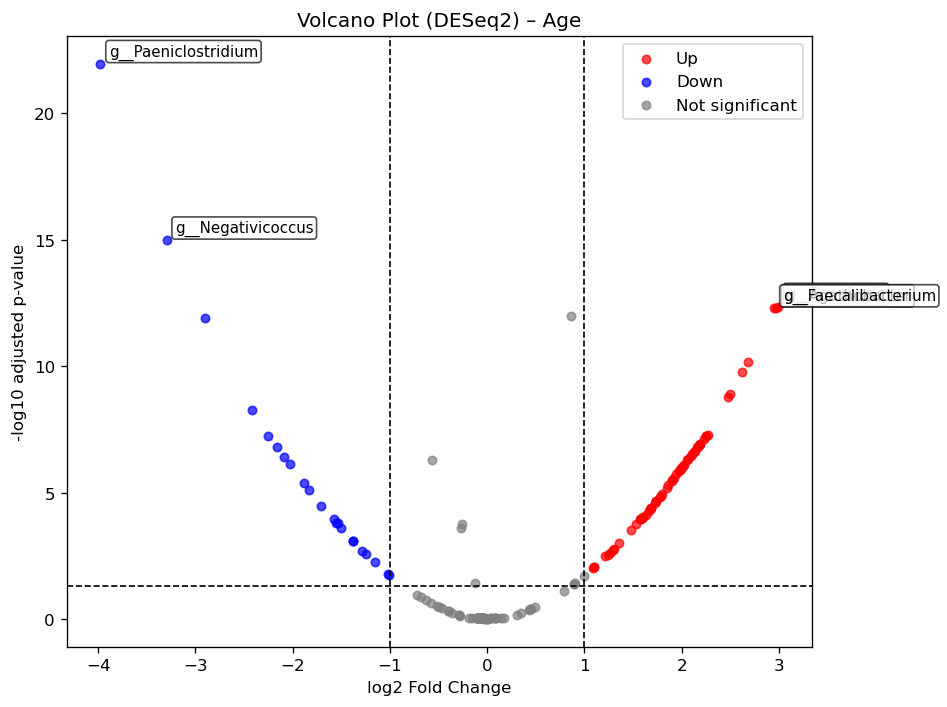

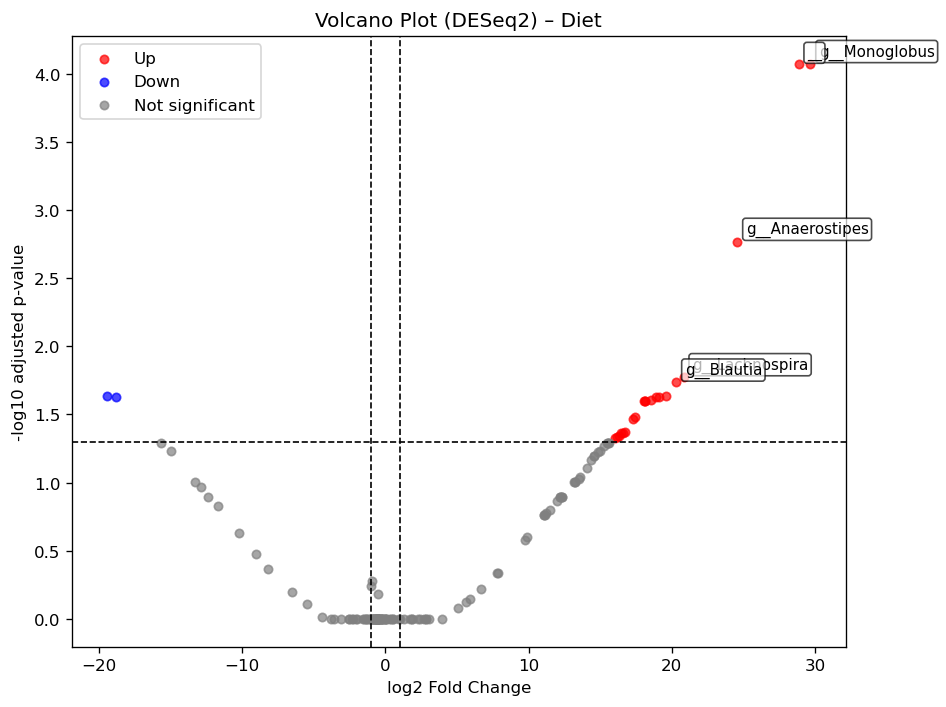

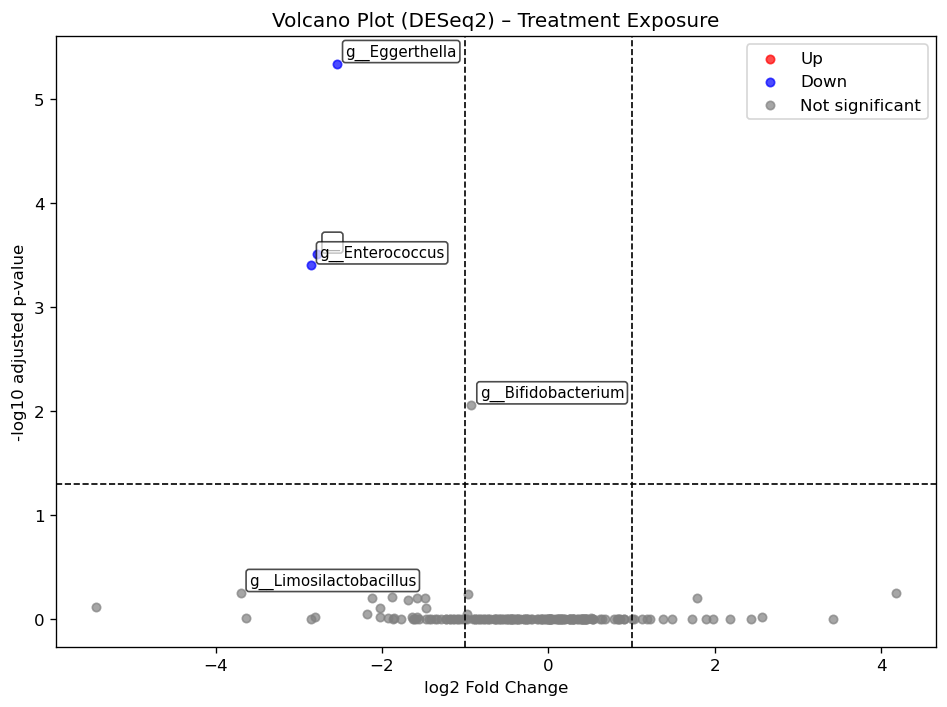

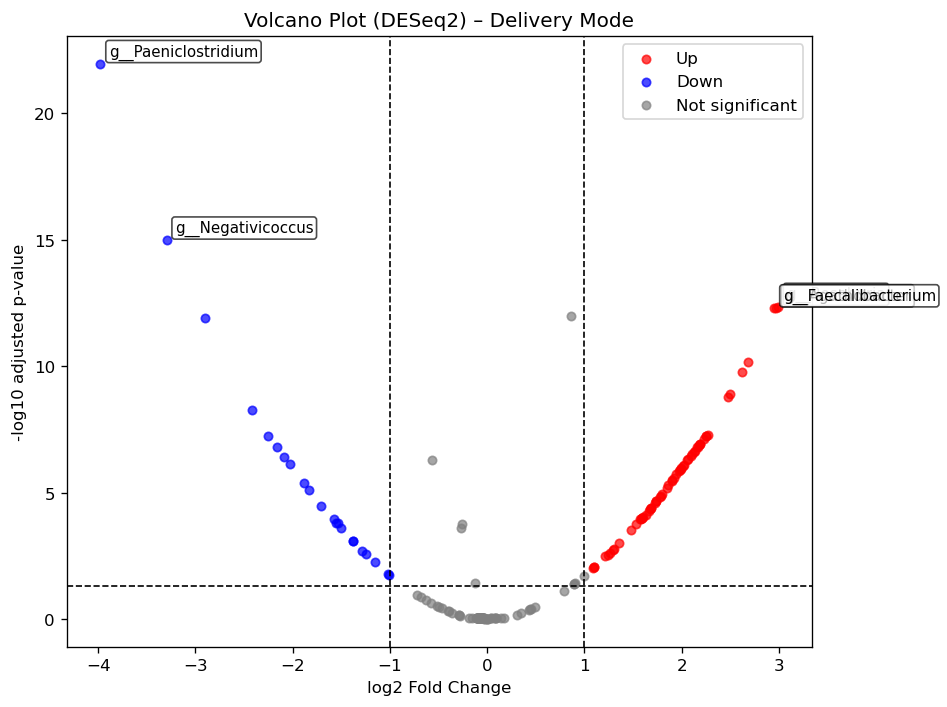

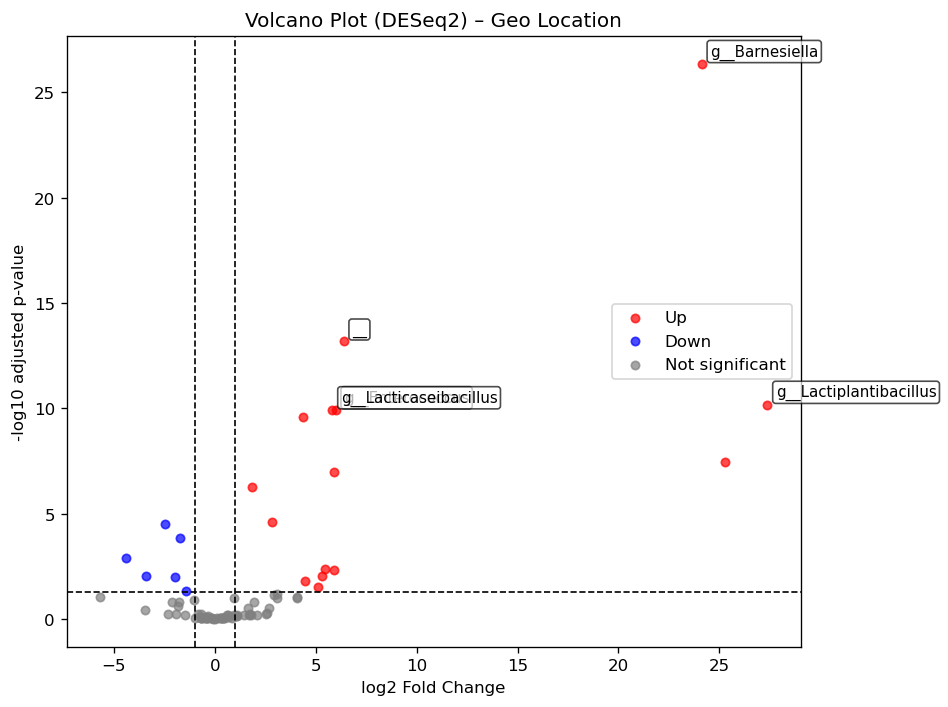

In [261]:
#This function creates and displays the deseq2 volcano plots

#helper function for labeling
def shorten_taxon(taxon):
    """Return only the last non-empty level (usually genus)."""
    parts = [p for p in taxon.split(";") if p]
    return parts[-1] if parts else taxon

def plot_volcano(df_path, alpha=0.05, lfc_thresh=1, top_n=10, title=None, dpi=120):
    """
    Generate a volcano plot from a DESeq2 results file with optional top N labeling.
    
    Parameters:
    - df_path: str, path to the DESeq2 results TSV
    - alpha: float, adjusted p-value threshold for significance
    - lfc_thresh: float, log2 fold change threshold
    - top_n: int, number of top significant features to label
    - title: str, optional plot title
    - dpi: int, figure dpi
    """
    # Load data
    df = pd.read_csv(df_path, sep="\t")
    
    # Remove rows with missing padj or log2FoldChange
    df = df.dropna(subset=["padj", "log2FoldChange"])
    
    # Compute -log10(padj)
    df["-log10_padj"] = -np.log10(df["padj"])
    
    # Categorize points
    df["sig"] = "Not significant"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] >= lfc_thresh), "sig"] = "Up"
    df.loc[(df["padj"] < alpha) & (df["log2FoldChange"] <= -lfc_thresh), "sig"] = "Down"
    
    # Define colors
    colors = {"Up": "red", "Down": "blue", "Not significant": "grey"}
    
    # Plot points
    plt.figure(figsize=(8,6), dpi=dpi)
    for cat, color in colors.items():
        subset = df[df["sig"] == cat]
        plt.scatter(
            subset["log2FoldChange"],
            subset["-log10_padj"],
            s=25,
            label=cat,
            c=color,
            alpha=0.7
        )
    
    # Threshold lines
    plt.axvline(x=lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axvline(x=-lfc_thresh, color="black", linestyle="--", linewidth=1)
    plt.axhline(y=-np.log10(alpha), color="black", linestyle="--", linewidth=1)
    
    # label most significant features
    top_df = df.sort_values("pvalue").head(5)

    for _, row in top_df.iterrows():
        label = shorten_taxon(row["Taxon"])
        plt.annotate(
            label,
            (row["log2FoldChange"], row["-log10_padj"]),
            textcoords="offset points",
            xytext=(5, 5),
            ha='left',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7)
        )
    
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10 adjusted p-value")
    if title is None:
        title = f"Volcano Plot – {df_path.split('/')[-1]}"
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    
#age
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_host_id_age_months.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Age"
)
#diet
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_host_id_diet_milk.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Diet"
)
#treatment
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_treatment_exposure.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Treatment Exposure"
)
#delivery mode
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_host_id_delivery_mode.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Delivery Mode"
)
#geo location
plot_volcano(
    df_path=f"{daa_data_dir}/DESeq2/results_deseq2_geo_location_name.tsv",
    alpha=0.05,
    lfc_thresh=1,
    top_n=10,
    title="Volcano Plot (DESeq2) – Geo Location"
)

# 5. Consensus sets

We created a consensus set from the results obtained above. 

What we have in the results files:
* ANCOM-BC: uses id column with taxonomy
* DESeq2: contains a Taxon column but no explicit feature ID
* Maaslin2: uses a feature column with taxonomy

What we need:
* Uniform feature ID column (taxonomy) across methods
* Merge all methods into a single consensus table

We also saw in the volcano plots that some of the differentially abundant features that were found were not classified up to the genus level. For the final consensus set we are only interested in the ones classified up to genus level, so that we can compare our results with what was found in other studies. Therefore we filter the results table to only contain feature_ids including "g__".

In [12]:
# create folder for consensus results
!mkdir -p "$daa_data_dir/consensus"

In [4]:
pd.set_option("display.max_colwidth", None)   # show full strings
pd.set_option("display.max_columns", None)    # show all columns
pd.set_option("display.width", None)          # no line wrapping

## 5.1 Age

We will first have a look at the output that we got from each of the three methods used above.

In [13]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_age = df_ancom_age
res_maaslin_age = pd.read_csv(f"{daa_data_dir}/maaslin/maaslin2_age/all_results.tsv", sep="\t")
res_deseq_age = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_host_id_age_months.tsv", sep="\t")

In [14]:
res_ancom_age.to_csv(f"{daa_data_dir}/consensus/res_ancom_age.tsv", sep="\t", index=False)
res_maaslin_age.to_csv(f"{daa_data_dir}/consensus/res_maaslin_age.tsv", sep="\t", index=False)
res_deseq_age.to_csv(f"{daa_data_dir}/consensus/res_deseq_age.tsv", sep="\t", index=False)

In [15]:
res_ancom_age.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-1.797778,5.471689e-07,1.699103e-06,0.358910,-5.008988,5.769780
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.309488,3.379349e-01,4.242161e-01,0.322971,-0.958254,0.372413
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-1.881011,2.347528e-05,6.021919e-05,0.444791,-4.228980,4.220265
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,2.105814,8.190603e-15,8.054093e-14,0.271207,7.764596,13.093983
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-1.263161,9.606869e-17,1.133611e-15,0.152013,-8.309546,14.945536


In [16]:
res_maaslin_age.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Blautia,age_group,m10,6.527891,0.496842,357,183,1.382648e-30,1.714483e-28
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Anaerostipes,age_group,m10,4.206623,0.411120,357,151,4.403611e-21,2.730239e-19
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Oscillospirales.f__Ruminococcaceae.g__Faecalibacterium,age_group,m10,5.293830,0.542634,357,144,1.246448e-19,5.151987e-18
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.__,age_group,m10,4.704451,0.485395,357,145,2.411551e-19,7.475810e-18
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Lachnospira,age_group,m10,3.967625,0.427947,357,94,4.239703e-18,1.051446e-16


In [17]:
res_deseq_age = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_age.tsv", sep="\t")
res_deseq_age.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,2051.674139,-0.262354,0.065898,-3.981193,6.857014e-05,1.801245e-04,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella
1,0.436072,-0.055800,0.385470,-0.144758,8.849019e-01,9.604927e-01,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005
2,11010.322879,-0.126846,0.053879,-2.354283,1.855848e-02,3.669991e-02,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium
3,0.853060,1.593470,0.385702,4.131350,3.606393e-05,1.057875e-04,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter
4,2321.032216,-0.565625,0.105764,-5.347971,8.894576e-08,5.218151e-07,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__


We can see that all of the results tables contain a column with the taxonomy. The seperator in the taxonomy from the maaslin table is "." so we will change that to ";" to match the other two tables. Additionally we will call the taxonomy colum "feature_id" in all of the tables so that we can use this column match the features them and build our consensus set.

In [59]:
#function to only keep features with genus-level annotation
import re

def filter_to_genus(df, feature_col="feature_id"):
    genus_regex = r"(;|^)g__[^;_][^;]*"
    return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [60]:
# Clean DeSEQ2
deseq = res_deseq_age.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_age = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Filter to genus-level annotations
deseq_clean_age = filter_to_genus(deseq_clean_age)

# Save file
deseq_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_age.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_age.rename(columns={"feature": "feature_id"})
maaslin["feature_id"] = maaslin["feature_id"].str.replace(".", ";", regex=False)

# Keep only clean output columns
maaslin_clean_age = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Filter to genus-level annotations
maaslin_clean_age = filter_to_genus(maaslin_clean_age)

# Save cleaned file
maaslin_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_age.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_age.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

# Keep only clean output colums
ancom_clean_age = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Filter to genus-level annotations
ancom_clean_age = filter_to_genus(ancom_clean_age)

# Save file
ancom_clean_age.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_age.tsv", sep="\t", index=False)

/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [61]:
ancom_clean_age.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-1.797778,0.358910,5.471689e-07,1.699103e-06,5.769780
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.309488,0.322971,3.379349e-01,4.242161e-01,0.372413
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,2.105814,0.271207,8.190603e-15,8.054093e-14,13.093983
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-1.263161,0.152013,9.606869e-17,1.133611e-15,14.945536
5,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,0.272839,0.272999,3.175943e-01,4.073492e-01,0.390033


In [62]:
maaslin_clean_age.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,6.527891,0.496842,1.382648e-30,1.714483e-28
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,4.206623,0.411120,4.403611e-21,2.730239e-19
2,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium,5.293830,0.542634,1.246448e-19,5.151987e-18
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnospira,3.967625,0.427947,4.239703e-18,1.051446e-16
5,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipelotrichales;f__Erysipelatoclostridiaceae;g__Thomasclavelia,4.459206,0.503029,1.313151e-16,2.713846e-15


In [63]:
deseq_clean_age.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-0.262354,0.065898,6.857014e-05,0.000180
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,-0.055800,0.385470,8.849019e-01,0.960493
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.126846,0.053879,1.855848e-02,0.036700
3,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter,1.593470,0.385702,3.606393e-05,0.000106
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,1.989157,0.383692,2.168868e-07,0.000001


Now that we have all the cleaned up dataframes, we can continue with building the consensus set. 

In [64]:
# Significance flags
deseq_sig_age = deseq_clean_age.assign(
    deseq_sig_age = deseq_clean_age["padj"] < 0.05
)

maaslin_sig_age = maaslin_clean_age.assign(
    maaslin_sig_age = maaslin_clean_age["qval"] < 0.05
)

ancom_sig_age = ancom_clean_age.assign(
    ancom_sig_age = ancom_clean_age["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_age = deseq_sig_age.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_age = maaslin_sig_age.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_age = ancom_sig_age.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_age = (
    deseq_sig_age
    .merge(maaslin_sig_age, on="feature_id", how="outer")
    .merge(ancom_sig_age, on="feature_id", how="outer")
)

We add a column called "n_significant" that contains the number of methods that found this feature to be significantly differentially abundant. This column will later be used to filter for the features that go into the consensus set.

In [65]:
# Count how many methods call a feature significant
consensus_age["n_significant"] = (
    consensus_age[["deseq_sig_age", "maaslin_sig_age", "ancom_sig_age"]]
    .sum(axis=1, skipna=True)
)


# Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_age["direction"] = consensus_age.apply(consensus_direction, axis=1)

In [66]:
consensus_age.to_csv(f"{daa_data_dir}/consensus/consensus_age.tsv", sep="\t", index=False)

The table created here contains all the features and all the statistical values that were outputted by the different methods. Additionally there is the "n_significant" and the "direction" column indicating if the feature is enriched (up) or depleted (down) or different directions were found by different methods (mixed).

In [67]:
consensus_age.head(20)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_age,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_age,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_age,n_significant,direction
0,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,-0.059748,0.384958,0.876659,0.960493,False,0.553901,0.191933,0.004184,0.009433,True,NaN,NaN,NaN,NaN,NaN,NaN,1,mixed
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,-0.059748,0.384958,0.876659,0.960493,False,0.099580,0.191848,0.604102,0.629485,False,NaN,NaN,NaN,NaN,NaN,NaN,0,mixed
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinotignum,-0.111604,0.385546,0.772222,0.960493,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,-0.633096,0.383248,0.098551,0.180677,False,0.512919,0.471709,0.277811,0.344486,False,-1.330094,0.214282,5.393199e-10,2.447683e-09,8.611245,True,1,down
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,-0.633096,0.383248,0.098551,0.180677,False,-0.482585,0.471523,0.306975,0.373185,False,-1.330094,0.214282,5.393199e-10,2.447683e-09,8.611245,True,1,down
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Varibaculum,-1.283120,0.385224,0.000866,0.001979,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,down
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.126846,0.053879,0.018558,0.036700,True,0.953431,0.380758,0.012910,0.024557,True,-0.309488,0.322971,3.379349e-01,4.242161e-01,0.372413,False,2,down
7,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.126846,0.053879,0.018558,0.036700,True,0.819155,0.380582,0.032315,0.054891,False,-0.309488,0.322971,3.379349e-01,4.242161e-01,0.372413,False,1,down
8,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,-0.520473,0.384653,0.176025,0.316126,False,-0.316360,0.241677,0.191603,0.250092,False,-1.222146,0.164020,9.248145e-14,7.794865e-13,12.108191,True,1,down
9,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,-0.520473,0.384653,0.176025,0.316126,False,-0.172373,0.241793,0.476505,0.527559,False,-1.222146,0.164020,9.248145e-14,7.794865e-13,12.108191,True,1,down


The final step is to filter out only the features that were found to be differentially abundant by all the ANCOM-BC, MaAsLin2 and DESeq2. 

In [68]:
#create final consensus set -> features are added if they were found to differentially abundant by all of the used methods
consensus_features_age = consensus_age[consensus_age["n_significant"] == 3]

final_consensus_age = consensus_features_age[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_age", "maaslin_sig_age", "ancom_sig_age",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_age.to_csv(f"{daa_data_dir}/consensus/final_consensus_age.tsv", sep="\t", index=False)

In [69]:
final_consensus_age

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_age,maaslin_sig_age,ancom_sig_age,n_significant,direction
27,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipelotrichales;f__Erysipelatoclostridiaceae;g__Thomasclavelia,1.215371,4.459206,1.851807,True,True,True,3,up
28,d__Bacteria;p__Bacillota;c__Bacilli;o__Erysipelotrichales;f__Erysipelatoclostridiaceae;g__Thomasclavelia,1.215371,3.052171,1.851807,True,True,True,3,up
129,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium,2.952280,5.293830,2.490616,True,True,True,3,up
115,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__Flavonifractor,1.940895,2.538754,1.102648,True,True,True,3,up
100,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Roseburia,2.988704,1.573255,1.490160,True,True,True,3,up
99,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Roseburia,2.988704,3.934066,1.490160,True,True,True,3,up
90,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnospira,2.623963,1.803161,1.732886,True,True,True,3,up
89,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Lachnospira,2.623963,3.967625,1.732886,True,True,True,3,up
71,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,2.499249,3.579209,3.289113,True,True,True,3,up
70,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,2.499249,6.527891,3.289113,True,True,True,3,up


In [70]:
final_consensus_age.shape

(20, 9)

This table shows the 20 differentially abundant features for age found by all of the methods. The increase in _Roseburia_ and _Blautia_ with age was also found by Sawhney et al. in 2021. But there are most certainly several factors, like changes in diet that influence the gut microbiome so we will have a look at these.

In the longitudinal analysis (notebook 06) we find that _Thomasclavelia_ and _Blautia_ also change with age, which we also see here. Research in mice suggests that _Thomasclavelia_ under a high-fat diet helps to reinforce the sugar and fat absorption [[Woting, A. et al., 2014](https://doi:10.1128/mBio.01530-14)]. _Blautia_ is a genus of anaerobic bacteria with probiotic characteristics that occur widely in the feces and intestines of mammals. Several studies have shown that changes in _Blautia_ population in the human intestine can be related to age, geography, diet and health [[Liu, X. et al., 2021](https://doi.org/10.1080/19490976.2021.1875796)].

The steps used to build the consensus sets for the other categories are the exact same as the ones used to build the consensus set for age. We therefore don't explain the single steps again.

## 5.2 Diet (dominantly breast fed and dominantly formula fed)

In [71]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_diet = df_ancom_diet
res_maaslin_diet = pd.read_csv(f"{daa_data_dir}/maaslin/maaslin2_diet/all_results.tsv", sep="\t")
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_host_id_diet_milk.tsv", sep="\t")

In [72]:
res_ancom_diet.to_csv(f"{daa_data_dir}/consensus/res_ancom_diet.tsv", sep="\t", index=False)
res_maaslin_diet.to_csv(f"{daa_data_dir}/consensus/res_maaslin_diet.tsv", sep="\t", index=False)
res_deseq_diet.to_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t", index=False)

In [73]:
res_ancom_diet.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-1.823507,3.406357e-03,0.016059,0.622683,-2.928469,1.794294
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,0.771474,1.765100e-01,0.332847,0.570795,1.351579,0.477755
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-1.420654,5.921161e-02,0.156319,0.753016,-1.886619,0.805989
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,1.591353,8.118429e-07,0.000026,0.322626,4.932499,4.578216
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-1.156924,1.786974e-05,0.000236,0.269681,-4.289970,3.627308


In [74]:
res_maaslin_diet.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Blautia,diet_milk,diet_milk,6.380055,0.917140,357,183,1.720652e-11,3.200412e-09
1,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.__,diet_milk,diet_milk,4.966796,0.814376,357,145,2.869484e-09,2.668620e-07
2,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Anaerostipes,diet_milk,diet_milk,4.288367,0.716757,357,151,5.392488e-09,3.343342e-07
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Oscillospirales.f__Ruminococcaceae.g__Faecalibacterium,diet_milk,diet_milk,4.832313,0.932435,357,144,3.705557e-07,1.723084e-05
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Peptostreptococcales.Tissierellales.f__Peptostreptococcaceae.g__Intestinibacter,diet_milk,mixed,3.141990,0.624023,357,209,8.088199e-07,3.008810e-05


In [75]:
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t")
res_deseq_diet.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,2167.488221,0.942381,5.905443,0.159578,0.873213,0.999836,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella
1,0.448770,-0.501097,5.930169,-0.084500,0.932659,NaN,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005
2,12177.323484,-0.518966,0.490560,-1.057905,0.290099,0.658134,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium
3,0.901872,-0.581574,5.931452,-0.098049,0.921893,0.999836,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter
4,2539.629103,-0.220314,1.061864,-0.207479,0.835636,0.999836,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__


In [76]:
# Clean DeSEQ2
deseq = res_deseq_diet.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_diet = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Filter to genus-level annotations
deseq_clean_diet = filter_to_genus(deseq_clean_diet)

# Save file
deseq_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_diet.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_diet.rename(columns={"feature": "feature_id"})
maaslin["feature_id"] = maaslin["feature_id"].str.replace(".", ";", regex=False)

# Keep only clean output columns
maaslin_clean_diet = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Filter to genus-level annotations
maaslin_clean_diet = filter_to_genus(maaslin_clean_diet)

# Save cleaned file
maaslin_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_diet.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_diet.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

# Keep only clean output columns
ancom_clean_diet = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Filter to genus-level annotations
ancom_clean_diet = filter_to_genus(ancom_clean_diet)

# Save file
ancom_clean_diet.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_diet.tsv", sep="\t", index=False)

/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [77]:
ancom_clean_diet.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-1.823507,0.622683,3.406357e-03,0.016059,1.794294
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,0.771474,0.570795,1.765100e-01,0.332847,0.477755
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,1.591353,0.322626,8.118429e-07,0.000026,4.578216
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-1.156924,0.269681,1.786974e-05,0.000236,3.627308
5,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,0.206380,0.418100,6.215782e-01,0.788926,0.102964


In [78]:
maaslin_clean_diet.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,6.380055,0.917140,1.720652e-11,3.200412e-09
2,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,4.288367,0.716757,5.392488e-09,3.343342e-07
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Faecalibacterium,4.832313,0.932435,3.705557e-07,1.723084e-05
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Peptostreptococcales;Tissierellales;f__Peptostreptococcaceae;g__Intestinibacter,3.141990,0.624023,8.088199e-07,3.008810e-05
6,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,4.010909,0.830990,2.147146e-06,4.900872e-05


In [79]:
deseq_clean_diet.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,0.942381,5.905443,0.873213,0.999836
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,-0.501097,5.930169,0.932659,NaN
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.518966,0.490560,0.290099,0.658134
3,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter,-0.581574,5.931452,0.921893,0.999836
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,24.574412,5.925176,0.000034,0.001703


In [80]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_diet = deseq_clean_diet.assign(
    deseq_sig_diet = deseq_clean_diet["padj"] < 0.05
)

maaslin_sig_diet = maaslin_clean_diet.assign(
    maaslin_sig_diet = maaslin_clean_diet["qval"] < 0.05
)

ancom_sig_diet= ancom_clean_age.assign(
    ancom_sig_diet = ancom_clean_diet["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_diet = deseq_sig_diet.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_diet = maaslin_sig_diet.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_diet = ancom_sig_diet.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_diet = (
    deseq_sig_diet
    .merge(maaslin_sig_diet, on="feature_id", how="outer")
    .merge(ancom_sig_diet, on="feature_id", how="outer")
)

In [81]:
# Count how many methods call a feature significant
consensus_diet["n_significant"] = (
    consensus_diet[["deseq_sig_diet", "maaslin_sig_diet", "ancom_sig_diet"]]
    .sum(axis=1, skipna=True)
)


# Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_diet["direction"] = consensus_diet.apply(consensus_direction, axis=1)

In [82]:
consensus_diet.to_csv(f"{daa_data_dir}/consensus/consensus_diet.tsv", sep="\t", index=False)

In [83]:
consensus_diet.head(10)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_diet,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_diet,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_diet,n_significant,direction
0,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,0.011494,5.924949,0.998452,0.999836,False,0.216717,0.322957,0.502636,0.603163,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,0.011494,5.924949,0.998452,0.999836,False,0.161646,0.279527,0.563465,0.642973,False,NaN,NaN,NaN,NaN,NaN,NaN,0,up
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,0.011494,5.924949,0.998452,0.999836,False,-0.088362,0.311889,0.777103,0.821257,False,NaN,NaN,NaN,NaN,NaN,NaN,0,mixed
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinotignum,-1.489451,5.927820,0.801610,0.999836,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,0.553874,5.915928,0.925408,0.999836,False,1.170370,0.772315,0.130571,0.237037,False,-1.330094,0.214282,5.393199e-10,2.447683e-09,8.611245,False,0,up
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,0.553874,5.915928,0.925408,0.999836,False,-0.664855,0.746183,0.373534,0.492081,False,-1.330094,0.214282,5.393199e-10,2.447683e-09,8.611245,False,0,down
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,0.553874,5.915928,0.925408,0.999836,False,0.409253,0.672675,0.543351,0.625840,False,-1.330094,0.214282,5.393199e-10,2.447683e-09,8.611245,False,0,up
7,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Varibaculum,-2.235489,5.923526,0.705883,0.999836,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
8,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.518966,0.490560,0.290099,0.658134,False,1.993757,0.670504,0.003146,0.016721,True,-0.309488,0.322971,3.379349e-01,4.242161e-01,0.372413,False,1,down
9,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.518966,0.490560,0.290099,0.658134,False,0.839211,0.554132,0.131006,0.237037,False,-0.309488,0.322971,3.379349e-01,4.242161e-01,0.372413,False,0,down


In [84]:
#create final consensus set -> features are added if they were found to differentially abundant all of the used methods
consensus_features_diet = consensus_diet[consensus_diet["n_significant"] == 3]

final_consensus_diet = consensus_features_diet[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_diet", "maaslin_sig_diet", "ancom_sig_diet",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_diet.to_csv(f"{daa_data_dir}/consensus/final_consensus_diet.tsv", sep="\t", index=False)

In [85]:
final_consensus_diet

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_diet,maaslin_sig_diet,ancom_sig_diet,n_significant,direction
85,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,24.574412,4.288367,2.105814,True,True,True,3,up
86,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,24.574412,3.434546,2.105814,True,True,True,3,up
87,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,24.574412,2.859460,2.105814,True,True,True,3,up
89,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,20.316100,6.380055,3.289113,True,True,True,3,up
90,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,20.316100,4.010909,3.289113,True,True,True,3,up
91,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Blautia,20.316100,4.523098,3.289113,True,True,True,3,up


In [86]:
final_consensus_diet.shape

(6, 9)

This table shows the 6 differentially abundant features for diet that were found by all three methods. We used breast-fed as the reference, so if the direction is up, it means that this feature was enriched in formula-fed children compared to breast-fed children. We exclusively found _Lachnospiraceae_ to be enriched in formula-fed children. This was also found by [[Ma et al., 2020](https://doi.org/10.1038/s41598-020-72635-x)]. 

## 5.3 Treatment exposure

In [43]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_treatment = df_ancom_treatment
res_maaslin_treatment = pd.read_csv(f"{daa_data_dir}/maaslin/maaslin2_treatment/all_results.tsv", sep="\t")
res_deseq_treatment = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_treatment_exposure.tsv", sep="\t")

In [44]:
res_ancom_treatment.to_csv(f"{daa_data_dir}/consensus/res_ancom_treatment.tsv", sep="\t", index=False)
res_maaslin_treatment.to_csv(f"{daa_data_dir}/consensus/res_maaslin_treatment.tsv", sep="\t", index=False)
res_deseq_treatment.to_csv(f"{daa_data_dir}/consensus/res_deseq_treatment.tsv", sep="\t", index=False)

In [45]:
res_ancom_treatment.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,1.172346,0.000081,0.001671,0.297410,3.941857,2.777032
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.358965,0.153169,0.439229,0.251301,-1.428427,0.357309
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-0.385150,0.277962,0.653824,0.355007,-1.084908,0.184539
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.282200,0.269431,0.653824,0.255529,-1.104373,0.184539
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,0.013335,0.918246,0.949187,0.129917,0.102643,0.022648


In [46]:
res_maaslin_treatment.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.__.__,treatment_exposure,True,-2.705409,0.581802,357,142,0.000007,0.000406
1,d__Bacteria.p__Actinomycetota.c__Coriobacteriia.o__Coriobacteriales.f__Eggerthellaceae.g__Eggerthella,treatment_exposure,True,-1.575281,0.358998,357,177,0.000021,0.000642
2,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.f__Enterococcaceae.g__Enterococcus,treatment_exposure,True,-1.747016,0.454166,357,134,0.000169,0.003498
3,d__Bacteria.p__Bacillota.c__Negativicutes.o__Veillonellales.Selenomonadales.f__Veillonellaceae.g__Veillonella,treatment_exposure,True,1.734776,0.473261,357,314,0.000336,0.005202
4,d__Bacteria.p__Pseudomonadota.c__Gammaproteobacteria.o__Pseudomonadales.f__Pseudomonadaceae.g__Pseudomonas,treatment_exposure,True,-0.730056,0.223147,357,74,0.001308,0.016214


In [47]:
res_deseq_diet = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_diet.tsv", sep="\t")
res_deseq_diet.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,2167.488221,0.942381,5.905443,0.159578,0.873213,0.999836,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella
1,0.448770,-0.501097,5.930169,-0.084500,0.932659,NaN,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005
2,12177.323484,-0.518966,0.490560,-1.057905,0.290099,0.658134,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium
3,0.901872,-0.581574,5.931452,-0.098049,0.921893,0.999836,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter
4,2539.629103,-0.220314,1.061864,-0.207479,0.835636,0.999836,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__


In [87]:
# Clean DeSEQ2
deseq = res_deseq_treatment.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_treatment = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Filter to genus-level annotations
deseq_clean_treatment = filter_to_genus(deseq_clean_treatment)

# Save file
deseq_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_treatment.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_treatment.rename(columns={"feature": "feature_id"})
maaslin["feature_id"] = maaslin["feature_id"].str.replace(".", ";", regex=False)

# Keep only clean output columns
maaslin_clean_treatment = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Filter to genus-level annotations
maaslin_clean_treatment = filter_to_genus(maaslin_clean_treatment)

# Save cleaned file
maaslin_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_treatment.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_treatment.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

#Keep only clean output columns
ancom_clean_treatment = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Filter to genus-level annotations
ancom_clean_treatment = filter_to_genus(ancom_clean_treatment)

# Save file
ancom_clean_treatment.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_treatment.tsv", sep="\t", index=False)

/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [88]:
ancom_clean_treatment.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,1.172346,0.297410,0.000081,0.001671,2.777032
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.358965,0.251301,0.153169,0.439229,0.357309
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.282200,0.255529,0.269431,0.653824,0.184539
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,0.013335,0.129917,0.918246,0.949187,0.022648
5,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,-0.926194,0.228820,0.000052,0.001603,2.794948


In [89]:
maaslin_clean_treatment.head()

,feature_id,coef,stderr,pval,qval
1,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,-1.575281,0.358998,0.000021,0.000642
2,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,-1.747016,0.454166,0.000169,0.003498
3,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales;Selenomonadales;f__Veillonellaceae;g__Veillonella,1.734776,0.473261,0.000336,0.005202
4,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Pseudomonadales;f__Pseudomonadaceae;g__Pseudomonas,-0.730056,0.223147,0.001308,0.016214
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,-1.277103,0.432056,0.003555,0.036737


In [90]:
deseq_clean_treatment.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,0.291359,0.284646,0.306031,0.998032
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,1.022585,2.565667,0.690214,0.998032
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.924951,0.248741,0.000200,0.008767
3,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter,0.840730,2.905300,0.772292,0.998032
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.131085,0.547390,0.810738,0.998032


In [91]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_treatment = deseq_clean_treatment.assign(
    deseq_sig_treatment = deseq_clean_treatment["padj"] < 0.05
)

maaslin_sig_treatment = maaslin_clean_treatment.assign(
    maaslin_sig_treatment = maaslin_clean_treatment["qval"] < 0.05
)

ancom_sig_treatment= ancom_clean_treatment.assign(
    ancom_sig_treatment = ancom_clean_treatment["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_treatment = deseq_sig_treatment.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_treatment = maaslin_sig_treatment.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_treatment = ancom_sig_treatment.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_treatment = (
    deseq_sig_treatment
    .merge(maaslin_sig_treatment, on="feature_id", how="outer")
    .merge(ancom_sig_treatment, on="feature_id", how="outer")
)

In [92]:
# Count how many methods call a feature significant
consensus_treatment["n_significant"] = (
    consensus_treatment[["deseq_sig_treatment", "maaslin_sig_treatment", "ancom_sig_treatment"]]
    .sum(axis=1, skipna=True)
)


# 5. Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_treatment["direction"] = consensus_treatment.apply(consensus_direction, axis=1)

In [93]:
consensus_treatment.to_csv(f"{daa_data_dir}/consensus/consensus_treatment.tsv", sep="\t", index=False)

In [94]:
consensus_treatment.head(10)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_treatment,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_treatment,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_treatment,n_significant,direction
0,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,-2.124320,1.034689,0.040063,0.626205,False,-0.351619,0.182560,0.055454,0.229212,False,-0.025399,0.118952,0.830918,0.949187,0.022648,False,0,down
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinotignum,0.375877,2.905520,0.897068,0.998032,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,up
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,-0.966625,0.425339,0.023050,0.576257,False,-1.277103,0.432056,0.003555,0.036737,True,-0.343734,0.185758,0.064250,0.330148,0.481291,False,1,down
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Varibaculum,-0.443289,1.452756,0.760262,0.998032,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.924951,0.248741,0.000200,0.008767,True,-1.036395,0.432786,0.017647,0.136764,False,-0.358965,0.251301,0.153169,0.439229,0.357309,False,1,down
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,-0.497793,0.922476,0.589454,0.998032,False,-0.205734,0.238601,0.389685,0.531229,False,0.090609,0.139021,0.514552,0.839533,0.075962,False,0,down
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Mycobacteriales;f__Corynebacteriaceae;g__Corynebacterium,-0.568487,2.905220,0.844862,0.998032,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
7,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Mycobacteriales;f__Corynebacteriaceae;g__Lawsonella,-0.634758,2.905298,0.827053,0.998032,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
8,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Atopobiaceae;g__Lancefieldella,-0.361889,0.894800,0.685893,0.998032,False,-0.159816,0.207783,0.442942,0.572133,False,0.112174,0.116945,0.337458,0.653824,0.184539,False,0,down
9,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Coriobacteriaceae;g__Collinsella,-1.475879,0.819118,0.071579,0.782891,False,-0.760810,0.530263,0.153138,0.365175,False,-0.151709,0.266684,0.569444,0.861110,0.064941,False,0,down


In [95]:
#create final consensus set -> features are added if they were found to differentially abundant by all of the used methods
consensus_features_treatment = consensus_treatment[consensus_treatment["n_significant"] == 3]

final_consensus_treatment = consensus_features_treatment[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_treatment", "maaslin_sig_treatment", "ancom_sig_treatment",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_treatment.to_csv(f"{daa_data_dir}/consensus/final_consensus_treatment.tsv", sep="\t", index=False)

In [96]:
final_consensus_treatment

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_treatment,maaslin_sig_treatment,ancom_sig_treatment,n_significant,direction
11,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,-2.538964,-1.575281,-0.926194,True,True,True,3,down
25,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,-2.852910,-1.747016,-1.117422,True,True,True,3,down


In [97]:
final_consensus_treatment.shape

(2, 9)

This table shows the 2 differentially abundant features for treatment exposure found by all three methods. This result has to be handled with some care because there was no correction for host_id in DeSeq2. 
These results would generally show if there is a difference between healthy infants and infants that get some form of treatment. So the the bacteria present in children recieving a treatment could be indicators of their disease or the treatment that they recieved. Eggerthella has been shown to have pathogenic potential [[Könönen, 2015](https://doi.org/10.1016/B978-1-4557-4801-3.00250-2)].

## 5.4 Delivery Mode

In [99]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_deliverymode = df_ancom_deliverymode
res_maaslin_deliverymode = pd.read_csv(f"{daa_data_dir}/maaslin/maaslin2_deliverymode/all_results.tsv", sep="\t")
res_deseq_deliverymode = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_host_id_delivery_mode.tsv", sep="\t")

In [100]:
res_ancom_deliverymode.to_csv(f"{daa_data_dir}/consensus/res_ancom_deliverymode.tsv", sep="\t", index=False)
res_maaslin_deliverymode.to_csv(f"{daa_data_dir}/consensus/res_maaslin_deliverymode.tsv", sep="\t", index=False)
res_deseq_deliverymode.to_csv(f"{daa_data_dir}/consensus/res_deseq_deliverymode.tsv", sep="\t", index=False)

In [101]:
res_ancom_deliverymode.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-0.976223,0.044489,0.250754,0.485814,-2.009458,0.600752
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.634323,0.119542,0.358993,0.407479,-1.556699,0.444915
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-2.386252,0.000007,0.000112,0.531807,-4.487064,3.951063
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.362064,0.408821,0.649921,0.438350,-0.825970,0.187139
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-0.209021,0.361772,0.605855,0.229191,-0.911993,0.217631


In [102]:
res_maaslin_deliverymode.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacteroidota.c__Bacteroidia.o__Bacteroidales.f__Bacteroidaceae.g__Bacteroides,delivery_mode,vaginal,5.491500,1.136528,357,281,0.000003,0.000168
1,d__Bacteria.p__Pseudomonadota.c__Gammaproteobacteria.o__Enterobacterales.f__Enterobacteriaceae.__,delivery_mode,vaginal,-3.226076,0.887939,357,230,0.000356,0.011026
2,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.f__Lactobacillaceae.__,delivery_mode,vaginal,-1.521526,0.474223,357,46,0.001608,0.033233
3,d__Bacteria.p__Bacillota.c__Clostridia.o__Lachnospirales.f__Lachnospiraceae.g__Mediterraneibacter,delivery_mode,vaginal,-1.549428,0.517025,357,47,0.003101,0.048061
4,d__Bacteria.p__Bacillota.c__Clostridia.o__Clostridiales.f__Clostridiaceae.g__Clostridium,delivery_mode,vaginal,-2.185012,0.844644,357,256,0.010426,0.107734


In [103]:
res_deseq_deliverymode = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_deliverymode.tsv", sep="\t")
res_deseq_deliverymode.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,2051.674139,-0.262354,0.065898,-3.981193,6.857014e-05,1.801245e-04,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella
1,0.436072,-0.055800,0.385470,-0.144758,8.849019e-01,9.604927e-01,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005
2,11010.322879,-0.126846,0.053879,-2.354283,1.855848e-02,3.669991e-02,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium
3,0.853060,1.593470,0.385702,4.131350,3.606393e-05,1.057875e-04,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter
4,2321.032216,-0.565625,0.105764,-5.347971,8.894576e-08,5.218151e-07,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__


In [104]:
# Clean DeSEQ2
deseq = res_deseq_deliverymode.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_deliverymode = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Filter to genus-level annotations
deseq_clean_deliverymode = filter_to_genus(deseq_clean_deliverymode)

# Save file
deseq_clean_deliverymode.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_deliverymode.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_deliverymode.rename(columns={"feature": "feature_id"})
maaslin["feature_id"] = maaslin["feature_id"].str.replace(".", ";", regex=False)

# Keep only clean output columns
maaslin_clean_deliverymode = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Filter to genus-level annotations
maaslin_clean_deliverymode = filter_to_genus(maaslin_clean_deliverymode)

# Save cleaned file
maaslin_clean_deliverymode.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_deliverymode.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_deliverymode.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

#Keep only clean output columns
ancom_clean_deliverymode = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Filter to genus-level annotations
ancom_clean_age = filter_to_genus(ancom_clean_age)

# Save file
ancom_clean_deliverymode.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_deliverymode.tsv", sep="\t", index=False)

/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [105]:
ancom_clean_deliverymode.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-0.976223,0.485814,0.044489,0.250754,0.600752
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.634323,0.407479,0.119542,0.358993,0.444915
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-2.386252,0.531807,0.000007,0.000112,3.951063
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.362064,0.438350,0.408821,0.649921,0.187139
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-0.209021,0.229191,0.361772,0.605855,0.217631


In [106]:
maaslin_clean_deliverymode.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides,5.491500,1.136528,0.000003,0.000168
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Mediterraneibacter,-1.549428,0.517025,0.003101,0.048061
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Clostridium,-2.185012,0.844644,0.010426,0.107734
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Peptostreptococcales;Tissierellales;f__Peptostreptococcaceae;g__Intestinibacter,-1.855947,0.705348,0.009207,0.107734
6,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Prevotellaceae;g__Hoylesella,-0.602680,0.249340,0.016148,0.139333


In [107]:
deseq_clean_deliverymode.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-0.262354,0.065898,6.857014e-05,0.000180
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,-0.055800,0.385470,8.849019e-01,0.960493
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.126846,0.053879,1.855848e-02,0.036700
3,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter,1.593470,0.385702,3.606393e-05,0.000106
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,1.989157,0.383692,2.168868e-07,0.000001


In [108]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_deliverymode = deseq_clean_deliverymode.assign(
    deseq_sig_deliverymode = deseq_clean_deliverymode["padj"] < 0.05
)

maaslin_sig_deliverymode = maaslin_clean_deliverymode.assign(
    maaslin_sig_deliverymode = maaslin_clean_deliverymode["qval"] < 0.05
)

ancom_sig_deliverymode= ancom_clean_deliverymode.assign(
    ancom_sig_deliverymode = ancom_clean_deliverymode["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_deliverymode = deseq_sig_deliverymode.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_deliverymode = maaslin_sig_deliverymode.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_deliverymode = ancom_sig_deliverymode.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_deliverymode = (
    deseq_sig_deliverymode
    .merge(maaslin_sig_deliverymode, on="feature_id", how="outer")
    .merge(ancom_sig_deliverymode, on="feature_id", how="outer")
)

In [109]:
# Count how many methods call a feature significant
consensus_deliverymode["n_significant"] = (
    consensus_deliverymode[["deseq_sig_deliverymode", "maaslin_sig_deliverymode", "ancom_sig_deliverymode"]]
    .sum(axis=1, skipna=True)
)


# 5. Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_deliverymode["direction"] = consensus_deliverymode.apply(consensus_direction, axis=1)

In [110]:
consensus_deliverymode.to_csv(f"{daa_data_dir}/consensus/consensus_deliverymode.tsv", sep="\t", index=False)

In [111]:
consensus_deliverymode.head(10)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_deliverymode,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_deliverymode,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_deliverymode,n_significant,direction
0,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,-0.059748,0.384958,0.876659,0.960493,False,-0.025980,0.311244,0.933547,0.949131,False,-0.160285,0.239053,0.502539,0.695797,0.157518,False,0,down
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinotignum,-0.111604,0.385546,0.772222,0.960493,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,-0.633096,0.383248,0.098551,0.180677,False,-1.179271,0.740591,0.112913,0.515132,False,-0.549616,0.314658,0.080688,0.323981,0.489480,False,0,down
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Varibaculum,-1.283120,0.385224,0.000866,0.001979,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,down
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,-0.126846,0.053879,0.018558,0.036700,True,-0.694281,0.724364,0.339003,0.724765,False,-0.634323,0.407479,0.119542,0.358993,0.444915,False,1,down
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,-0.520473,0.384653,0.176025,0.316126,False,0.562985,0.400461,0.161267,0.515132,False,0.218110,0.183447,0.234458,0.452441,0.344438,False,0,up
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Mycobacteriales;f__Corynebacteriaceae;g__Corynebacterium,-0.089920,0.385607,0.815614,0.960493,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
7,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Mycobacteriales;f__Corynebacteriaceae;g__Lawsonella,-0.094339,0.385551,0.806701,0.960493,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,down
8,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Atopobiaceae;g__Lancefieldella,-0.109523,0.384861,0.775967,0.960493,False,-0.191639,0.349896,0.584558,0.823695,False,-0.171676,0.191290,0.369471,0.605855,0.217631,False,0,down
9,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Coriobacteriaceae;g__Collinsella,-0.581749,0.384323,0.130102,0.236061,False,0.248883,0.880690,0.777794,0.902597,False,-0.016641,0.466728,0.971558,0.971558,0.012531,False,0,down


In [115]:
#create final consensus set -> features are added if they were found to differentially abundant all of the used methods
consensus_features_deliverymode = consensus_deliverymode[consensus_deliverymode["n_significant"] == 3]

final_consensus_deliverymode = consensus_features_deliverymode[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_deliverymode", "maaslin_sig_deliverymode", "ancom_sig_deliverymode",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_deliverymode.to_csv(f"{daa_data_dir}/consensus/final_consensus_deliverymode.tsv", sep="\t", index=False)

In [116]:
final_consensus_deliverymode

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_deliverymode,maaslin_sig_deliverymode,ancom_sig_deliverymode,n_significant,direction
74,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Mediterraneibacter,2.056183,-1.549428,-1.042959,True,True,True,3,down


In [117]:
final_consensus_deliverymode.shape

(1, 9)

This table shows the one differentially abundant feature found by all three methods. I could not find any literature backing up this result or even connecting _Mediterraneibacter_ to delivery mode.

## 5.5 Geo Location

In [134]:
# adjusting the results dataframes so they all contain the same information and the colums have the same names
res_ancom_geolocation = df_ancom_geolocation
res_maaslin_geolocation = pd.read_csv(f"{daa_data_dir}/maaslin/maaslin2_geolocation/all_results.tsv", sep="\t")
res_deseq_geolocation = pd.read_csv(f"{daa_data_dir}/DESeq2/results_deseq2_geo_location_name.tsv", sep="\t")

In [119]:
res_ancom_geolocation.to_csv(f"{daa_data_dir}/consensus/res_ancom_geolocation.tsv", sep="\t", index=False)
res_maaslin_geolocation.to_csv(f"{daa_data_dir}/consensus/res_maaslin_geolocation.tsv", sep="\t", index=False)
res_deseq_geolocation.to_csv(f"{daa_data_dir}/consensus/res_deseq_geolocation.tsv", sep="\t", index=False)

In [120]:
res_ancom_geolocation.head()

,id,lfc,p_val,q_val,se,w,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-3.317340,8.631484e-21,5.610465e-19,0.354734,-9.351621,18.251001
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.701623,4.933495e-11,4.581103e-10,0.258883,6.572929,9.339030
2,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__,-0.198031,6.335544e-01,8.236208e-01,0.415395,-0.476730,0.084273
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.072296,8.135968e-01,8.966603e-01,0.306616,-0.235788,0.047372
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-0.694948,6.482515e-07,4.213635e-06,0.139653,-4.976258,5.375343


In [121]:
res_maaslin_geolocation.head()

,feature,metadata,value,coef,stderr,N,N.not.0,pval,qval
0,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.f__Enterococcaceae.g__Enterococcus,geo_location_name,Finland,-4.593941,0.440434,357,134,1.119367e-19,1.388015e-17
1,d__Bacteria.p__Bacillota.c__Negativicutes.o__Veillonellales.Selenomonadales.f__Veillonellaceae.g__Veillonella,geo_location_name,Finland,4.663806,0.459586,357,314,3.161782e-19,1.960305e-17
2,d__Bacteria.p__Bacillota.c__Negativicutes.o__Veillonellales.Selenomonadales.f__Veillonellaceae.g__Veillonella,geo_location_name,Estonia,5.046917,0.547901,357,314,5.925312e-17,2.449129e-15
3,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.__.__,geo_location_name,Finland,-5.152432,0.614775,357,142,1.412392e-14,4.378416e-13
4,d__Bacteria.p__Bacillota.c__Bacilli.o__Lactobacillales.f__Enterococcaceae.g__Enterococcus,geo_location_name,Estonia,-4.333260,0.522255,357,134,2.757696e-14,6.839086e-13


In [122]:
res_deseq_geolocation = pd.read_csv(f"{daa_data_dir}/consensus/res_deseq_geolocation.tsv", sep="\t")
res_deseq_geolocation.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Taxon
0,2051.674139,-1.740947,0.409504,-4.251356,2.124801e-05,1.434240e-04,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella
1,0.233639,-1.380111,3.948772,-0.349504,7.267111e-01,NaN,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005
2,11010.322879,1.828195,0.336930,5.426034,5.762015e-08,5.185813e-07,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium
3,0.092314,-1.148467,4.268647,-0.269047,7.878935e-01,NaN,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter
4,1175.608461,-0.689341,0.621787,-1.108646,2.675830e-01,5.557493e-01,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Enterobacteriaceae;__


In [123]:
# Clean DeSEQ2
deseq = res_deseq_geolocation.rename(columns={"Taxon": "feature_id"})
deseq["feature_id"] = deseq["feature_id"].astype(str)

# Keep only clean output columns
deseq_clean_geolocation = deseq[[
    "feature_id", "log2FoldChange", "lfcSE", "pvalue", "padj"
]]

# Filter to genus-level annotations
deseq_clean_geolocation = filter_to_genus(deseq_clean_geolocation)

# Save file
deseq_clean_geolocation.to_csv(f"{daa_data_dir}/consensus/clean_deseq2_geolocation.tsv", sep="\t", index=False)


# Clean MaAsLin2
maaslin = res_maaslin_geolocation.rename(columns={"feature": "feature_id"})
maaslin["feature_id"] = maaslin["feature_id"].str.replace(".", ";", regex=False)

# Keep only clean output columns
maaslin_clean_geolocation = maaslin[[
    "feature_id", "coef", "stderr", "pval", "qval"
]]

# Filter to genus-level annotations
maaslin_clean_geolocation = filter_to_genus(maaslin_clean_geolocation)

# Save cleaned file
maaslin_clean_geolocation.to_csv(f"{daa_data_dir}/consensus/clean_maaslin2_geolocation.tsv", sep="\t", index=False)


# Clean ANCOM-BC
ancom = res_ancom_geolocation.rename(columns={"id": "feature_id"})
ancom["feature_id"] = ancom["feature_id"].astype(str)

#Keep only clean output columns
ancom_clean_geolocation = ancom[[
    "feature_id", "lfc", "se", "p_val", "q_val", "minus_log10_q"
]]

# Filter to genus-level annotations
ancom_clean_geolocation = filter_to_genus(ancom_clean_geolocation)

# Save file
ancom_clean_geolocation.to_csv(f"{daa_data_dir}/consensus/clean_ancombc_geolocation.tsv", sep="\t", index=False)

/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]
/tmp/ipykernel_68/3489178102.py:6: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return df[df[feature_col].str.contains(genus_regex, regex=True)]


In [124]:
ancom_clean_geolocation.head()

,feature_id,lfc,se,p_val,q_val,minus_log10_q
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-3.317340,0.354734,8.631484e-21,5.610465e-19,18.251001
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.701623,0.258883,4.933495e-11,4.581103e-10,9.339030
3,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,-0.072296,0.306616,8.135968e-01,8.966603e-01,0.047372
4,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Ruminococcaceae;g__Acutalibacter,-0.694948,0.139653,6.482515e-07,4.213635e-06,5.375343
5,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,1.042140,0.334956,1.862843e-03,6.726933e-03,2.172183


In [125]:
maaslin_clean_geolocation.head()

,feature_id,coef,stderr,pval,qval
0,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,-4.593941,0.440434,1.119367e-19,1.388015e-17
1,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales;Selenomonadales;f__Veillonellaceae;g__Veillonella,4.663806,0.459586,3.161782e-19,1.960305e-17
2,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales;Selenomonadales;f__Veillonellaceae;g__Veillonella,5.046917,0.547901,5.925312e-17,2.449129e-15
4,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,-4.333260,0.522255,2.757696e-14,6.839086e-13
6,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Pseudomonadales;f__Pseudomonadaceae;g__Pseudomonas,-2.143665,0.276800,5.834775e-13,1.033589e-11


In [126]:
deseq_clean_geolocation.head()

,feature_id,log2FoldChange,lfcSE,pvalue,padj
0,d__Bacteria;p__Bacillota;c__Negativicutes;o__Veillonellales-Selenomonadales;f__Veillonellaceae;g__Veillonella,-1.740947,0.409504,2.124801e-05,1.434240e-04
1,d__Bacteria;p__Bacillota;c__Clostridia;o__Oscillospirales;f__Oscillospiraceae;g__UCG-005,-1.380111,3.948772,7.267111e-01,NaN
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.828195,0.336930,5.762015e-08,5.185813e-07
3,d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales;f__Pasteurellaceae;g__Aggregatibacter,-1.148467,4.268647,7.878935e-01,NaN
5,d__Bacteria;p__Bacillota;c__Clostridia;o__Lachnospirales;f__Lachnospiraceae;g__Anaerostipes,0.631092,0.803528,4.322180e-01,6.732626e-01


In [127]:
# Significance flags (same as for age, just here for completeness and so it can be run independantly)
deseq_sig_geolocation = deseq_clean_geolocation.assign(
    deseq_sig_geolocation = deseq_clean_geolocation["padj"] < 0.05
)

maaslin_sig_geolocation = maaslin_clean_geolocation.assign(
    maaslin_sig_geolocation = maaslin_clean_geolocation["qval"] < 0.05
)

ancom_sig_geolocation = ancom_clean_geolocation.assign(
    ancom_sig_geolocation = ancom_clean_geolocation["q_val"] < 0.05
)


# Rename columns for merging clarity
deseq_sig_geolocation = deseq_sig_geolocation.rename(columns={
    "log2FoldChange": "deseq_lfc",
    "pvalue": "deseq_p",
    "padj": "deseq_q"
})

maaslin_sig_geolocation = maaslin_sig_geolocation.rename(columns={
    "coef": "maaslin_lfc",
    "pval": "maaslin_p",
    "qval": "maaslin_q"
})

ancom_sig_geolocation = ancom_sig_geolocation.rename(columns={
    "lfc": "ancom_lfc",
    "p_val": "ancom_p",
    "q_val": "ancom_q"
})


# Merge all results on feature_id
consensus_geolocation = (
    deseq_sig_geolocation
    .merge(maaslin_sig_geolocation, on="feature_id", how="outer")
    .merge(ancom_sig_geolocation, on="feature_id", how="outer")
)

In [128]:
# Count how many methods call a feature significant
consensus_geolocation["n_significant"] = (
    consensus_geolocation[["deseq_sig_geolocation", "maaslin_sig_geolocation", "ancom_sig_geolocation"]]
    .sum(axis=1, skipna=True)
)


# 5. Determine consensus direction -> majority vote among LFC signs
def consensus_direction(row):
    signs = []

    for col in ["deseq_lfc", "maaslin_lfc", "ancom_lfc"]:
        val = row[col]
        if pd.notnull(val):
            if val > 0:
                signs.append(1)
            elif val < 0:
                signs.append(-1)

    if len(signs) == 0:
        return None
    
    total = sum(signs)
    if total > 0:
        return "up"
    elif total < 0:
        return "down"
    else:
        return "mixed"

consensus_geolocation["direction"] = consensus_geolocation.apply(consensus_direction, axis=1)

In [129]:
consensus_geolocation.to_csv(f"{daa_data_dir}/consensus/consensus_geolocation.tsv", sep="\t", index=False)

In [130]:
consensus_geolocation.head(10)

,feature_id,deseq_lfc,lfcSE,deseq_p,deseq_q,deseq_sig_geolocation,maaslin_lfc,stderr,maaslin_p,maaslin_q,maaslin_sig_geolocation,ancom_lfc,se,ancom_p,ancom_q,minus_log10_q,ancom_sig_geolocation,n_significant,direction
0,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,3.205419,1.535819,3.687838e-02,NaN,False,-0.763018,0.260327,3.707417e-03,1.768153e-02,True,-0.038795,0.164800,8.138917e-01,8.966603e-01,0.047372,False,1,down
1,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinomyces,3.205419,1.535819,3.687838e-02,NaN,False,-0.378146,0.219826,8.678842e-02,1.805948e-01,False,-0.038795,0.164800,8.138917e-01,8.966603e-01,0.047372,False,0,down
2,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Actinotignum,0.204052,4.269879,9.618847e-01,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,up
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,2.818468,0.603262,2.982100e-06,2.415501e-05,True,-3.247368,0.582294,7.935583e-08,9.840123e-07,True,0.843773,0.234397,3.185111e-04,1.217837e-03,2.914411,True,3,up
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,2.818468,0.603262,2.982100e-06,2.415501e-05,True,-2.308751,0.489189,4.748827e-06,4.213806e-05,True,0.843773,0.234397,3.185111e-04,1.217837e-03,2.914411,True,3,up
5,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Varibaculum,0.549869,2.054453,7.889707e-01,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,up
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.828195,0.336930,5.762015e-08,5.185813e-07,True,-2.785003,0.487206,4.248235e-08,5.853124e-07,True,1.701623,0.258883,4.933495e-11,4.581103e-10,9.339030,True,3,up
7,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.828195,0.336930,5.762015e-08,5.185813e-07,True,-1.331705,0.572617,2.103376e-02,6.382351e-02,False,1.701623,0.258883,4.933495e-11,4.581103e-10,9.339030,True,2,up
8,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,0.387590,1.379064,7.786696e-01,8.748766e-01,False,-0.134039,0.343352,6.966489e-01,8.227092e-01,False,-0.287579,0.170726,9.209568e-02,1.760653e-01,0.754326,False,0,down
9,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Micrococcales;f__Micrococcaceae;g__Rothia,0.387590,1.379064,7.786696e-01,8.748766e-01,False,0.097268,0.290949,7.385066e-01,8.557635e-01,False,-0.287579,0.170726,9.209568e-02,1.760653e-01,0.754326,False,0,up


In [131]:
#create final consensus set -> features are added if they were found to differentially abundant by all of the used methods
consensus_features_geolocation = consensus_geolocation[consensus_geolocation["n_significant"] == 3]

final_consensus_geolocation = consensus_features_geolocation[[
    "feature_id",
    "deseq_lfc", "maaslin_lfc", "ancom_lfc",
    "deseq_sig_geolocation", "maaslin_sig_geolocation", "ancom_sig_geolocation",
    "n_significant",
    "direction"
]].sort_values("n_significant", ascending=False)

final_consensus_geolocation.to_csv(f"{daa_data_dir}/consensus/final_consensus_geolocation.tsv", sep="\t", index=False)

In [132]:
final_consensus_geolocation

,feature_id,deseq_lfc,maaslin_lfc,ancom_lfc,deseq_sig_geolocation,maaslin_sig_geolocation,ancom_sig_geolocation,n_significant,direction
3,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,2.818468,-3.247368,0.843773,True,True,True,3,up
4,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Actinomycetales;f__Actinomycetaceae;g__Schaalia,2.818468,-2.308751,0.843773,True,True,True,3,up
6,d__Bacteria;p__Actinomycetota;c__Actinobacteria;o__Bifidobacteriales;f__Bifidobacteriaceae;g__Bifidobacterium,1.828195,-2.785003,1.701623,True,True,True,3,up
17,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,4.384468,-2.004228,1.042140,True,True,True,3,up
18,d__Bacteria;p__Actinomycetota;c__Coriobacteriia;o__Coriobacteriales;f__Eggerthellaceae;g__Eggerthella,4.384468,-2.354036,1.042140,True,True,True,3,up
35,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,5.987040,-4.593941,3.285274,True,True,True,3,up
36,d__Bacteria;p__Bacillota;c__Bacilli;o__Lactobacillales;f__Enterococcaceae;g__Enterococcus,5.987040,-4.333260,3.285274,True,True,True,3,up
59,d__Bacteria;p__Bacillota;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Clostridium,-2.439615,2.998664,-2.383272,True,True,True,3,down
60,d__Bacteria;p__Bacillota;c__Clostridia;o__Clostridiales;f__Clostridiaceae;g__Clostridium,-2.439615,2.286547,-2.383272,True,True,True,3,down
190,d__Bacteria;p__Campylobacterota;c__Campylobacteria;o__Campylobacterales;f__Campylobacteraceae;g__Campylobacter,-3.418526,1.359047,-1.214389,True,True,True,3,down


In [133]:
final_consensus_geolocation.shape

(13, 9)

This table shows the 13 differentially abundant features for geo location found by all three methods. This result has to be handled with some care because there was no correction for host_id in DeSeq2. We found _Eggerthella_ and _Enterococcus_ also in the different treatment groups. _Bifidobacterium_ was found to be more abundant in Russian children than in Fisnish children by [[Vantanen et al., 2016](https://doi:10.1016/j.cell.2016.04.007)], which matches what we see here. 

<div style="border: 2px solid #1f77b4; padding: 10px; border-radius: 6px; background-color: #eaf3fb;">
    
<b> Research questions this notebook answers:</b>
    
- How do the microbiome samples differ between different ages? What differences do you see in terms of geolocation? What could be covariates contributing to these changes?
The microbiome does change between different ages. We found that among others there was an increase in _Thomasclavelia_, _Roseburia_ and _Blautia_. But the enrichments and depletions of microbes found in the age class have to be handled with some care since we found in literature that geographical location, diet, delivery mode and health status can all have impacts and contribute to the results. In the longitudinal analysis (notebook 06) we find that _Thomasclavelia_ and _Blautia_ also change with age, which backs up the results found in this notebook.
    
- Some of your samples were exposed to some treatment (metadata column "treatment_exposure").  Did the treatment have an effect on the infant gut microbiome?  Does the effect of the treatment depend on other covariates?
For the two treatment exposure groups we found _Eggerthella_ and _Enterococcus_ to be enriched in the treatment = True group. We found these two also in the geolocation groups where we compared Finland and Russia. So in this case it is not possible to say if the change stems from the difference in treatment or the difference in location. 

</div>

## References

Nearing, J.T., Douglas, G.M., Hayes, M.G. et al. Microbiome differential abundance methods produce different results across 38 datasets. Nat Commun 13, 342 (2022). https://doi.org/10.1038/s41467-022-28034-z

Lin, H., Peddada, S.D. Analysis of compositions of microbiomes with bias correction. Nat Commun 11, 3514 (2020). https://doi.org/10.1038/s41467-020-17041-7

Sawhney, S.S., Thänert, R., Thänert, A. et al. Gut microbiome evolution from infancy to 8 years of age. Nat Med 31, 2004–2015 (2025). https://doi.org/10.1038/s41591-025-03610-0

Woting A, Pfeiffer N, Loh G, Klaus S, Blaut M. Clostridium ramosum promotes high-fat diet-induced obesity in gnotobiotic mouse models. mBio. (2014). https://doi:10.1128/mBio.01530-14

Liu, X., Mao, B., Gu, J., Wu, J., Cui, S., Wang, G., … Chen, W. (2021). Blautia—a new functional genus with potential probiotic properties? Gut Microbes, 13(1). https://doi.org/10.1080/19490976.2021.1875796

Ma, J., Li, Z., Zhang, W. et al. Comparison of gut microbiota in exclusively breast-fed and formula-fed babies: a study of 91 term infants. Sci Rep 10, 15792 (2020). https://doi.org/10.1038/s41598-020-72635-x

Könönen, E. Anaerobic Cocci and Anaerobic Gram-Positive Nonsporulating Bacilli. Mandell, Douglas, and Bennett's Principles and Practice of Infectious Diseases (Eighth Edition), W.B. Saunders, 2015, Pages 2781-2786.e2, https://doi.org/10.1016/B978-1-4557-4801-3.00250-2.

Vatanen T, Kostic AD, d'Hennezel E, Siljander H, Franzosa EA, Yassour M, Kolde R, Vlamakis H, Arthur TD, Hämäläinen AM, Peet A, Tillmann V, Uibo R, Mokurov S, Dorshakova N, Ilonen J, Virtanen SM, Szabo SJ, Porter JA, Lähdesmäki H, Huttenhower C, Gevers D, Cullen TW, Knip M; DIABIMMUNE Study Group; Xavier RJ. Variation in Microbiome LPS Immunogenicity Contributes to Autoimmunity in Humans. Cell. 2016 May 5;165(4):842-53. doi:10.1016/j.cell.2016.04.007.


<span style="color:gray">
   
### **Citations for Methods**
    
Huang Lin and Shyamal Das Peddada. Analysis of compositions of microbiomes with bias correction. Nature communications, 11(1):3514, 2020. URL: https://www.nature.com/articles/s41467-020-17041-7, doi:10.1038/s41467-020-17041-7.
    
Mallick H, Rahnavard A, McIver LJ, Ma S, Zhang Y, Nguyen LH, Tickle TL, Weingart G, Ren B, Schwager EH, Chatterjee S, Thompson KN, Wilkinson JE, Subramanian A, Lu Y, Waldron L, Paulson JN, Franzosa EA, Bravo HC, Huttenhower C (2021). Multivariable Association Discovery in Population-scale Meta-omics Studies. PLoS Computational Biology, 17(11):e1009442.
    
Love, M.I., Huber, W., Anders, S. (2014) Moderated estimation of fold change and dispersion for RNA-seq data with DESeq2. Genome Biology, 15:550. 10.1186/s13059-014-0550-8
    